In [1]:
! pip install python-dotenv pandas openai tiktoken matplotlib


[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import sys
sys.path.append('..')
sys.path.append('../..')
sys.path.append('ci_cd')
sys.path.append('../../lamoom')
import dotenv
dotenv.load_dotenv('..')
import pandas as pd
results = {}
testing_pipes = {}

In [3]:
from lamoom import Prompt
from lamoom.ai_models.tools.web_tool import WEB_SEARCH_TOOL, BEST_CUSTOMER_EXPERIENCE_TOOL, MAKE_PLAN_TOOL, UPDATE_PLAN_TOOL 

agent = Prompt(id="answer_on_legal_question")

agent.add("""
Answer on the question, make a research if qneeded.          
Please first think out loud before answering.
""", role="system")

agent.add("""{question}""", role="user")

agent.add_tool(BEST_CUSTOMER_EXPERIENCE_TOOL)
agent.add_tool(MAKE_PLAN_TOOL)
agent.add_tool(UPDATE_PLAN_TOOL)
agent.add_tool(WEB_SEARCH_TOOL)


In [4]:
from lamoom import Lamoom
client = Lamoom()

In [5]:
import os
openai_key = os.getenv("OPENAI_API_KEY")

In [6]:
legal_qa_v1_df = pd.read_csv("hf://datasets/dzunggg/legal-qa-v1/legal_qa_full.csv")
# add index column, add a new column with index for legal_qa_v1_df
legal_qa_v1_df['index'] = legal_qa_v1_df.index
legal_qa_v1_df.head()

/Users/kateyanchenka/projects/lamoom-python/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,question,answer,index
0,Q: I was wondering if a pain management office...,"A:In Kentucky, your situation raises questions...",0
1,Q: My houseboat was moved while I was at work ...,A:If your houseboat was moved without your per...,1
2,Q: Wondering if I could sue a dealership if I’...,"A:Yes, you can sue a dealership if you have ha...",2
3,Q: Do I need to file for CS & custody through ...,A:Once all parties have moved to another state...,3
4,"Q: I am planning on releasing a tabletop rpg ""...",A:It's difficult to determine whether there is...,4


In [7]:
final_df = legal_qa_v1_df.copy()

In [8]:
ideal_answer_statements = {}

In [9]:
from researches.ci_cd.TestLLMResponsePipe import TestLLMResponsePipe
from researches.ci_cd.responses import Statement


if not os.path.exists('ideal_answer_statements.json'):
    for index, row in final_df.iterrows():
        id_row = row['index']
        question = row['question']
        answer = row['answer']

        ideal_answer_statements[id_row] = TestLLMResponsePipe.generate_statements(
            question=question,
            ideal_answer=answer
        )
        print(f"Processed row {id_row}: {ideal_answer_statements[id_row]}")
        import json
    with open('ideal_answer_statements.json', 'w') as f:
        formatted_json = {k: [stmt.to_dict() for stmt in v if stmt] for k, v in ideal_answer_statements.items() if v}
        json.dump(formatted_json, f)
else:
    import json
    with open('ideal_answer_statements.json', 'r') as f:
        ideal_answer_statements_json = json.load(f)
    ideal_answer_statements = {int(k): [Statement(**stmt) for stmt in v] for k, v in ideal_answer_statements_json.items()}

In [10]:
target_models = [
    # "claude/claude-opus-4-1-20250805",
    "claude/claude-3-7-sonnet-20250219"
]
testing_pipes = {}
for model in target_models:
    if model not in testing_pipes:
        testing_pipes[model] = TestLLMResponsePipe(lamoom=client)

In [11]:
target_models_results = {}

Unified messages: [{'role': 'system', 'content': '\nAnswer on the question, make a research if qneeded.          \nPlease first think out loud before answering.\n\n\nYou have next tools available:\n```\n//Provides reasoning from the perspective of a customer to enhance understanding of customer needs and improve service quality.\n1. Start from best_customer_experience\n```\n<tool_call>\n{\n"tool_name": "best_customer_experience",\n"parameters": {\n"reasoning": "As a customer I want to ..."\n},\n}\n</tool_call>\n## BEST CUSTOMER EXPERIENCE\n{best_customer_experience}\n- best_customer_experience({"reasoning": ... \\ string - (The reasoning from the customer\'s perspective.)})\nCan be called 1 times.\n\n\n//Creates a structured plan with steps to achieve a specific goal. Each step should include expected results, actions to take, and the current state.\n\n2. Continue from making a plan, and after going through each step and mark it you\'re on the step:\n\n<tool_call>\n{\n"tool_name": "mak

Error executing tool 'update_plan', Please try second time.
Traceback (most recent call last):
  File "/Users/kateyanchenka/projects/lamoom-python/researches/../lamoom/ai_models/ai_model.py", line 388, in handle_tool_call
    result = tool_function.execution_function(**parameters)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: update_plan() got an unexpected keyword argument 'step_name'


handled tool call ToolCallResult:
tool_name=update_plan
parameters={'step_name': {'step5': {'expected_results': 'Provide actionable next steps for the patient', 'actions': 'Outline possible courses of action the patient can take based on our findings', 'where_we_are': 'We have analyzed the legal framework, standard practices, potential retaliation aspects, and available remedies, and can now provide concrete recommendations'}}}
execution_result=Error executing tool 'update_plan', Please try second time.
update_json_context=False
executed ToolCallResult:
tool_name=update_plan
parameters={'step_name': {'step5': {'expected_results': 'Provide actionable next steps for the patient', 'actions': 'Outline possible courses of action the patient can take based on our findings', 'where_we_are': 'We have analyzed the legal framework, standard practices, potential retaliation aspects, and available remedies, and can now provide concrete recommendations'}}}
execution_result=Error executing tool 'upd

Error executing tool 'update_plan', Please try second time.
Traceback (most recent call last):
  File "/Users/kateyanchenka/projects/lamoom-python/researches/../lamoom/ai_models/ai_model.py", line 388, in handle_tool_call
    result = tool_function.execution_function(**parameters)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: update_plan() got an unexpected keyword argument 'step_name'


handled tool call ToolCallResult:
tool_name=update_plan
parameters={'step_name': 'step5', 'expected_results': 'Provide actionable next steps for the patient', 'actions': 'Outline possible courses of action the patient can take based on our findings', 'where_we_are': 'We have analyzed the legal framework, standard practices, potential retaliation aspects, and available remedies, and can now provide concrete recommendations'}
execution_result=Error executing tool 'update_plan', Please try second time.
update_json_context=False
executed ToolCallResult:
tool_name=update_plan
parameters={'step_name': 'step5', 'expected_results': 'Provide actionable next steps for the patient', 'actions': 'Outline possible courses of action the patient can take based on our findings', 'where_we_are': 'We have analyzed the legal framework, standard practices, potential retaliation aspects, and available remedies, and can now provide concrete recommendations'}
execution_result=Error executing tool 'update_plan

/Users/kateyanchenka/projects/lamoom-python/researches/../researches/ci_cd/TestLLMResponsePipe.py:351: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


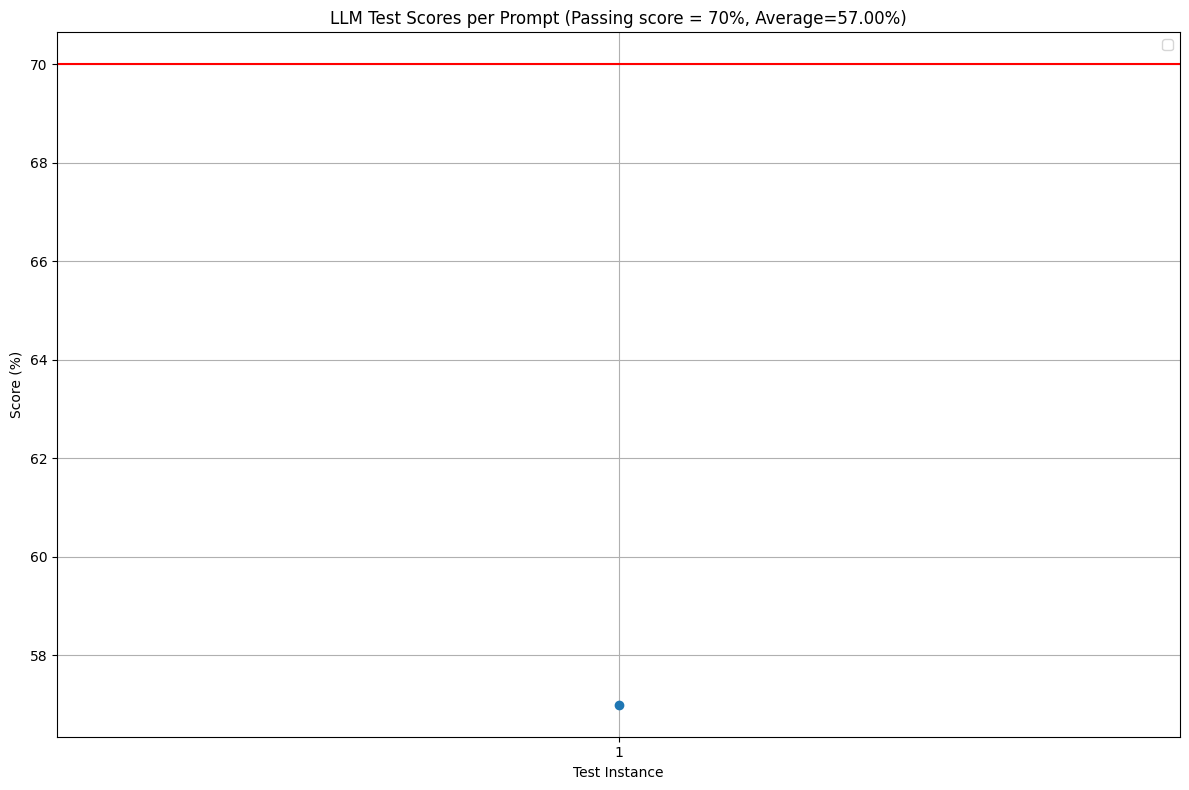

Unified messages: [{'role': 'system', 'content': '\nAnswer on the question, make a research if qneeded.          \nPlease first think out loud before answering.\n\n\nYou have next tools available:\n```\n//Provides reasoning from the perspective of a customer to enhance understanding of customer needs and improve service quality.\n1. Start from best_customer_experience\n```\n<tool_call>\n{\n"tool_name": "best_customer_experience",\n"parameters": {\n"reasoning": "As a customer I want to ..."\n},\n}\n</tool_call>\n## BEST CUSTOMER EXPERIENCE\n{best_customer_experience}\n- best_customer_experience({"reasoning": ... \\ string - (The reasoning from the customer\'s perspective.)})\nCan be called 0 times.\n\n\n//Creates a structured plan with steps to achieve a specific goal. Each step should include expected results, actions to take, and the current state.\n\n2. Continue from making a plan, and after going through each step and mark it you\'re on the step:\n\n<tool_call>\n{\n"tool_name": "mak

Tool 'web_call' not found in registry: dict_keys([])


handled tool call ToolCallResult:
tool_name=web_call
parameters={'query': 'wrongful lien on houseboat legal remedies marina eviction laws'}
execution_result=
update_json_context=False
executed ToolCallResult:
tool_name=web_call
parameters={'query': 'wrongful lien on houseboat legal remedies marina eviction laws'}
execution_result=
update_json_context=False
Unified messages: [{'role': 'system', 'content': '\nAnswer on the question, make a research if qneeded.          \nPlease first think out loud before answering.\n\n\nYou have next tools available:\n```\n//Provides reasoning from the perspective of a customer to enhance understanding of customer needs and improve service quality.\n1. Start from best_customer_experience\n```\n<tool_call>\n{\n"tool_name": "best_customer_experience",\n"parameters": {\n"reasoning": "As a customer I want to ..."\n},\n}\n</tool_call>\n## BEST CUSTOMER EXPERIENCE\n{best_customer_experience}\n- best_customer_experience({"reasoning": ... \\ string - (The reaso

Tool 'web_call' not found in registry: dict_keys([])


handled tool call ToolCallResult:
tool_name=web_call
parameters={'query': 'liveaboard houseboat tenant rights marina'}
execution_result=
update_json_context=False
executed ToolCallResult:
tool_name=web_call
parameters={'query': 'liveaboard houseboat tenant rights marina'}
execution_result=
update_json_context=False
Unified messages: [{'role': 'system', 'content': '\nAnswer on the question, make a research if qneeded.          \nPlease first think out loud before answering.\n\n\nYou have next tools available:\n```\n//Provides reasoning from the perspective of a customer to enhance understanding of customer needs and improve service quality.\n1. Start from best_customer_experience\n```\n<tool_call>\n{\n"tool_name": "best_customer_experience",\n"parameters": {\n"reasoning": "As a customer I want to ..."\n},\n}\n</tool_call>\n## BEST CUSTOMER EXPERIENCE\n{best_customer_experience}\n- best_customer_experience({"reasoning": ... \\ string - (The reasoning from the customer\'s perspective.)})\

...

handled tool call ToolCallResult:
tool_name=web_call
parameters={'query': 'marina lien laws houseboat seizure legal rights'}
execution_result=
update_json_context=False
executed ToolCallResult:
tool_name=web_call
parameters={'query': 'marina lien laws houseboat seizure legal rights'}
execution_result=
update_json_context=False
Unified messages: [{'role': 'system', 'content': '\nAnswer on the question, make a research if qneeded.          \nPlease first think out loud before answering.\n\n\nYou have next tools available:\n```\n//Provides reasoning from the perspective of a customer to enhance understanding of customer needs and improve service quality.\n1. Start from best_customer_experience\n```\n<tool_call>\n{\n"tool_name": "best_customer_experience",\n"parameters": {\n"reasoning": "As a customer I want to ..."\n},\n}\n</tool_call>\n## BEST CUSTOMER EXPERIENCE\n{best_customer_experience}\n- best_customer_experience({"reasoning": ... \\ string - (The reasoning from the customer\'s pers

Tool 'web_call' not found in registry: dict_keys([])


handled tool call ToolCallResult:
tool_name=web_call
parameters={'query': 'can marina owner place lien on boat without notice state laws'}
execution_result=
update_json_context=False
executed ToolCallResult:
tool_name=web_call
parameters={'query': 'can marina owner place lien on boat without notice state laws'}
execution_result=
update_json_context=False
Unified messages: [{'role': 'system', 'content': '\nAnswer on the question, make a research if qneeded.          \nPlease first think out loud before answering.\n\n\nYou have next tools available:\n```\n//Provides reasoning from the perspective of a customer to enhance understanding of customer needs and improve service quality.\n1. Start from best_customer_experience\n```\n<tool_call>\n{\n"tool_name": "best_customer_experience",\n"parameters": {\n"reasoning": "As a customer I want to ..."\n},\n}\n</tool_call>\n## BEST CUSTOMER EXPERIENCE\n{best_customer_experience}\n- best_customer_experience({"reasoning": ... \\ string - (The reasoni

Tool 'make_plan' not found in registry: dict_keys([])


handled tool call ToolCallResult:
tool_name=make_plan
parameters={'steps': {'step1': {'expected_results': 'Understand the basic legal framework applicable to this situation', 'actions': 'Outline general legal principles regarding marina/houseboat relationships, tenant rights for liveaboards, and lien laws', 'where_we_are': 'Need to establish legal context for advice'}, 'step2': {'expected_results': 'Identify potential legal claims based on the facts provided', 'actions': 'Analyze possible legal violations including improper eviction, improper lien, discrimination, and property damage', 'where_we_are': 'Understanding what legal rights may have been violated'}, 'step3': {'expected_results': 'Outline immediate actions to protect legal rights', 'actions': 'Recommend documentation gathering, legal consultation options, and time-sensitive steps', 'where_we_are': 'Need to provide actionable first steps'}, 'step4': {'expected_results': 'Provide information on longer-term legal remedies', 'acti

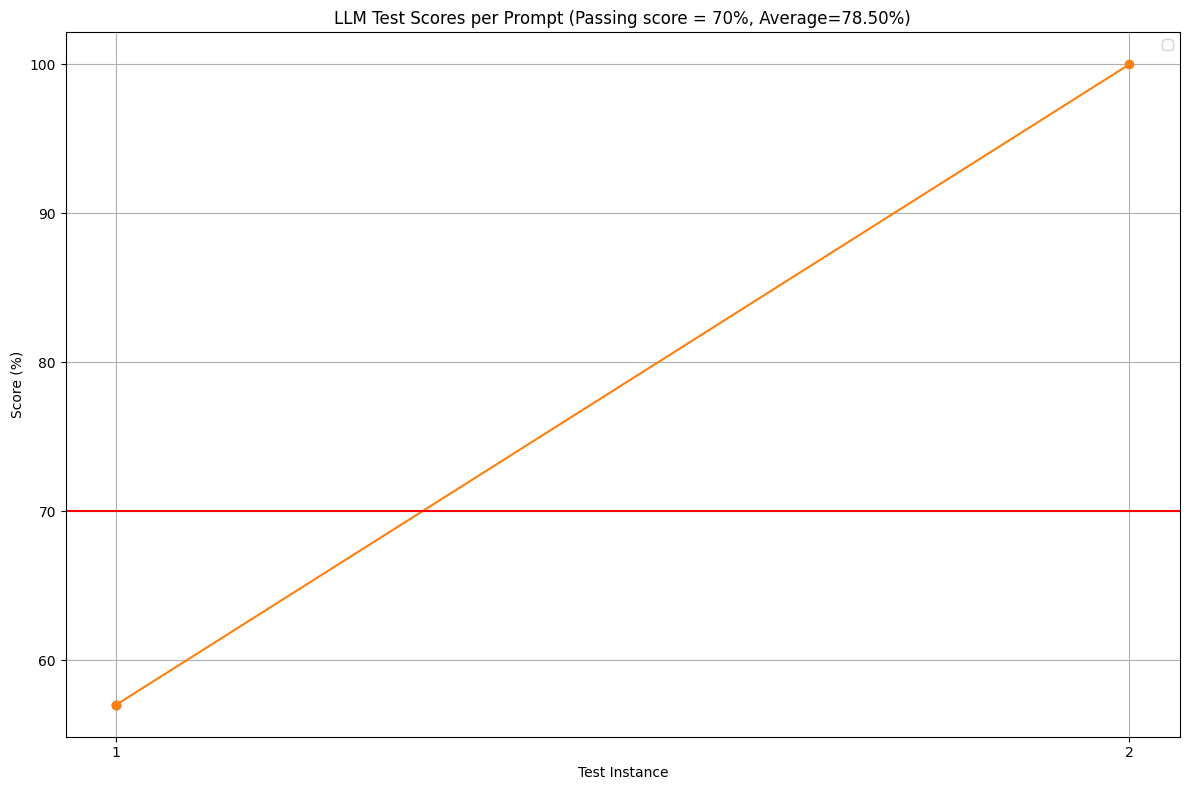

Unified messages: [{'role': 'system', 'content': '\nAnswer on the question, make a research if qneeded.          \nPlease first think out loud before answering.\n\n\nYou have next tools available:\n```\n//Provides reasoning from the perspective of a customer to enhance understanding of customer needs and improve service quality.\n1. Start from best_customer_experience\n```\n<tool_call>\n{\n"tool_name": "best_customer_experience",\n"parameters": {\n"reasoning": "As a customer I want to ..."\n},\n}\n</tool_call>\n## BEST CUSTOMER EXPERIENCE\n{best_customer_experience}\n- best_customer_experience({"reasoning": ... \\ string - (The reasoning from the customer\'s perspective.)})\nCan be called -1 times.\n\n\n//Creates a structured plan with steps to achieve a specific goal. Each step should include expected results, actions to take, and the current state.\n\n2. Continue from making a plan, and after going through each step and mark it you\'re on the step:\n\n<tool_call>\n{\n"tool_name": "ma

Error executing tool 'update_plan', Please try second time.
Traceback (most recent call last):
  File "/Users/kateyanchenka/projects/lamoom-python/researches/../lamoom/ai_models/ai_model.py", line 388, in handle_tool_call
    result = tool_function.execution_function(**parameters)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: update_plan() got an unexpected keyword argument 'step_name'


handled tool call ToolCallResult:
tool_name=update_plan
parameters={'step_name': {'step1': {'expected_results': 'Understand if lemon laws apply to this 2018 Ford Expedition purchase', 'actions': 'Research lemon law basics and whether they apply to used vehicles and the age/mileage of this vehicle', 'where_we_are': "Lemon laws vary by state with more limited protection for used vehicles. Eligibility depends on: 1) Whether purchased from a dealer (required for lemon law coverage), 2) Vehicle's age and mileage, 3) If it was under manufacturer warranty when purchased, 4) If a dealer warranty was provided. Ford Expedition transmission issues appear to be a known problem, which could strengthen the case. Even if lemon laws don't apply, other legal remedies exist including warranty claims, Magnuson-Moss Warranty Act, state consumer protection laws, and breach of contract claims."}}}
execution_result=Error executing tool 'update_plan', Please try second time.
update_json_context=False
executed

Error executing tool 'update_plan', Please try second time.
Traceback (most recent call last):
  File "/Users/kateyanchenka/projects/lamoom-python/researches/../lamoom/ai_models/ai_model.py", line 388, in handle_tool_call
    result = tool_function.execution_function(**parameters)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: update_plan() got an unexpected keyword argument 'step_name'


handled tool call ToolCallResult:
tool_name=update_plan
parameters={'step_name': 'step1', 'expected_results': 'Understand if lemon laws apply to this 2018 Ford Expedition purchase', 'actions': 'Research lemon law basics and whether they apply to used vehicles and the age/mileage of this vehicle', 'where_we_are': 'Lemon laws vary by state with more limited protection for used vehicles. Eligibility depends on: dealer purchase, vehicle age/mileage, and warranty status. Ford Expedition transmission issues appear to be a known problem. Alternative legal remedies include warranty claims, Magnuson-Moss Warranty Act, state consumer protection laws, and breach of contract claims.'}
execution_result=Error executing tool 'update_plan', Please try second time.
update_json_context=False
executed ToolCallResult:
tool_name=update_plan
parameters={'step_name': 'step1', 'expected_results': 'Understand if lemon laws apply to this 2018 Ford Expedition purchase', 'actions': 'Research lemon law basics and 

Error executing tool 'update_plan', Please try second time.
Traceback (most recent call last):
  File "/Users/kateyanchenka/projects/lamoom-python/researches/../lamoom/ai_models/ai_model.py", line 388, in handle_tool_call
    result = tool_function.execution_function(**parameters)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: update_plan() got an unexpected keyword argument 'step_name'


handled tool call ToolCallResult:
tool_name=update_plan
parameters={'step_name': 'step1', 'expected_results': 'Understand if lemon laws apply to this 2018 Ford Expedition purchase', 'actions': 'Research lemon law basics and whether they apply to used vehicles and the age/mileage of this vehicle', 'where_we_are': 'Lemon laws vary by state with limited used vehicle protection. Eligibility depends on dealer purchase, age/mileage, and warranty status. Ford Expedition transmission issues are known problems. Alternative remedies include warranty claims and consumer protection laws.'}
execution_result=Error executing tool 'update_plan', Please try second time.
update_json_context=False
executed ToolCallResult:
tool_name=update_plan
parameters={'step_name': 'step1', 'expected_results': 'Understand if lemon laws apply to this 2018 Ford Expedition purchase', 'actions': 'Research lemon law basics and whether they apply to used vehicles and the age/mileage of this vehicle', 'where_we_are': 'Lemon 

Some characters could not be decoded, and were replaced with REPLACEMENT CHARACTER.


handled tool call ToolCallResult:
tool_name=web_call
parameters={'query': '2018 Ford Expedition powertrain warranty coverage duration transmission'}
execution_result=<result_1>
Title: 2018 Model Year Ford Warranty Guide
URL: https://www.ford.com/cmslibs/content/dam/brand_ford/en_us/brand/resources/general/pdf/warranty/2018-Ford-Car-Lt-Truck-Warranty-version-3_frdwa_EN-US_08_2017.pdf
Snippet: (1) Your vehicle's Powertrain components are covered for five years or. 60,000 ... During the warranty coverage period, Ford Motor Company warrants that:.
Content: %PDF-1.6
%����
129 0 obj
<>
endobj
165 0 obj
<>/Filter/FlateDecode/ID[<3A1240FCAA59E442A5A7A4A86F74DB65>]/Index[129 140]/Info 128 0 R/Length 168/Prev 7003496/Root 130 0 R/Size 269/Type/XRef/W[1 3 1]>>stream
h���1AA��y�Y���8�
5�V�v��(E��	HJ�(H�@^���gP��˟ٌٙ:���H�e������*������`~ݎ^�6h�SG�1�o��t��6�=�9lzӅ��i�
&{��Q?�P]�є�WsYOD��
����O�J�M��<�'� X1

endstream
endobj
startxref
0
%%EOF
267 0 obj
<>stream
h�Ē�kQ��؝��
�+

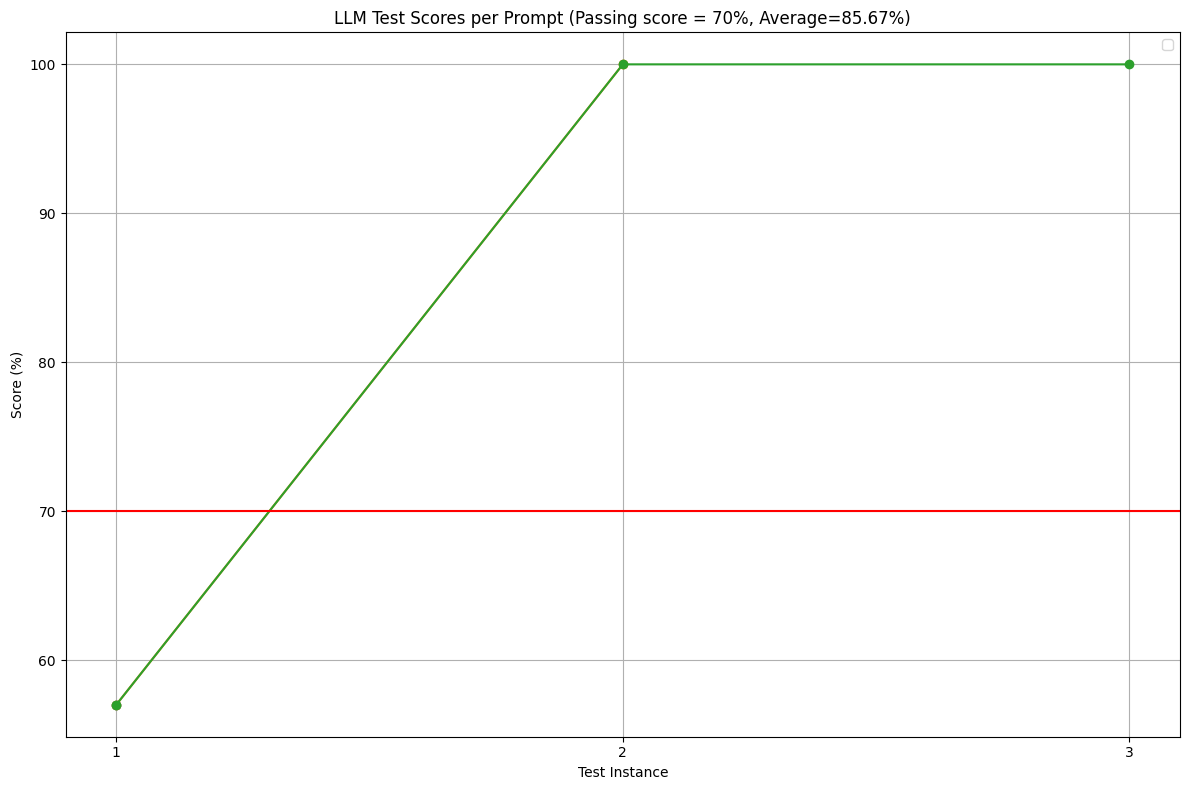

Unified messages: [{'role': 'system', 'content': '\nAnswer on the question, make a research if qneeded.          \nPlease first think out loud before answering.\n\n\nYou have next tools available:\n```\n//Provides reasoning from the perspective of a customer to enhance understanding of customer needs and improve service quality.\n1. Start from best_customer_experience\n```\n<tool_call>\n{\n"tool_name": "best_customer_experience",\n"parameters": {\n"reasoning": "As a customer I want to ..."\n},\n}\n</tool_call>\n## BEST CUSTOMER EXPERIENCE\n{best_customer_experience}\n- best_customer_experience({"reasoning": ... \\ string - (The reasoning from the customer\'s perspective.)})\nCan be called -2 times.\n\n\n//Creates a structured plan with steps to achieve a specific goal. Each step should include expected results, actions to take, and the current state.\n\n2. Continue from making a plan, and after going through each step and mark it you\'re on the step:\n\n<tool_call>\n{\n"tool_name": "ma

Error executing tool 'update_plan', Please try second time.
Traceback (most recent call last):
  File "/Users/kateyanchenka/projects/lamoom-python/researches/../lamoom/ai_models/ai_model.py", line 388, in handle_tool_call
    result = tool_function.execution_function(**parameters)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: update_plan() got an unexpected keyword argument 'step_name'


handled tool call ToolCallResult:
tool_name=update_plan
parameters={'step_name': {'step1': {'expected_results': 'Understand the legal framework for tribal court orders and their recognition in state courts', 'actions': 'Research the relationship between tribal court orders and state court enforcement', 'where_we_are': "Tribal court orders may be recognized through various legal mechanisms: Full Faith and Credit for Child Support Orders Act (FFCCSOA), Uniform Interstate Family Support Act (UIFSA), and Uniform Child Custody Jurisdiction and Enforcement Act (UCCJEA). Since 2008, UIFSA amendments include Indian tribes as 'states' for enforcement purposes. Recognition varies by state - some use comity principles rather than full faith and credit."}}}
execution_result=Error executing tool 'update_plan', Please try second time.
update_json_context=False
executed ToolCallResult:
tool_name=update_plan
parameters={'step_name': {'step1': {'expected_results': 'Understand the legal framework for tr

Error executing tool 'update_plan', Please try second time.
Traceback (most recent call last):
  File "/Users/kateyanchenka/projects/lamoom-python/researches/../lamoom/ai_models/ai_model.py", line 388, in handle_tool_call
    result = tool_function.execution_function(**parameters)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: update_plan() got an unexpected keyword argument 'step_name'


handled tool call ToolCallResult:
tool_name=update_plan
parameters={'step_name': 'step1', 'expected_results': 'Understand the legal framework for tribal court orders and their recognition in state courts', 'actions': 'Research the relationship between tribal court orders and state court enforcement', 'where_we_are': "Tribal court orders may be recognized through various legal mechanisms: Full Faith and Credit for Child Support Orders Act (FFCCSOA), Uniform Interstate Family Support Act (UIFSA), and Uniform Child Custody Jurisdiction and Enforcement Act (UCCJEA). Since 2008, UIFSA amendments include Indian tribes as 'states' for enforcement purposes. Recognition varies by state - some use comity principles rather than full faith and credit."}
execution_result=Error executing tool 'update_plan', Please try second time.
update_json_context=False
executed ToolCallResult:
tool_name=update_plan
parameters={'step_name': 'step1', 'expected_results': 'Understand the legal framework for tribal c

Error executing tool 'update_plan', Please try second time.
Traceback (most recent call last):
  File "/Users/kateyanchenka/projects/lamoom-python/researches/../lamoom/ai_models/ai_model.py", line 388, in handle_tool_call
    result = tool_function.execution_function(**parameters)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: update_plan() got an unexpected keyword argument 'step_name'


handled tool call ToolCallResult:
tool_name=update_plan
parameters={'step_name': 'step1', 'expected_results': 'Understand the legal framework for tribal court orders and their recognition in state courts', 'actions': 'Research the relationship between tribal court orders and state court enforcement', 'where_we_are': "Tribal court orders may be recognized through various legal mechanisms: Full Faith and Credit for Child Support Orders Act (FFCCSOA), Uniform Interstate Family Support Act (UIFSA), and Uniform Child Custody Jurisdiction and Enforcement Act (UCCJEA). Since 2008, UIFSA amendments include Indian tribes as 'states' for enforcement purposes. Recognition varies by state - some use comity principles rather than full faith and credit."}
execution_result=Error executing tool 'update_plan', Please try second time.
update_json_context=False
executed ToolCallResult:
tool_name=update_plan
parameters={'step_name': 'step1', 'expected_results': 'Understand the legal framework for tribal c

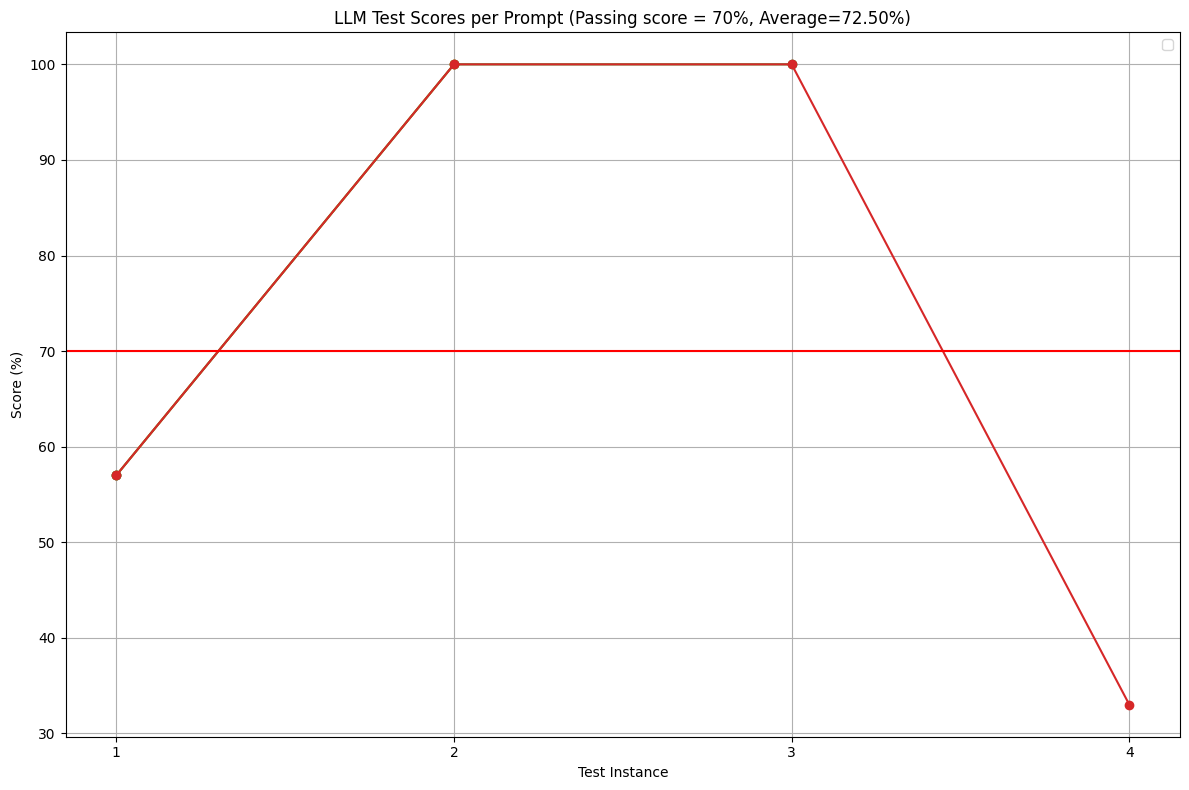

Unified messages: [{'role': 'system', 'content': '\nAnswer on the question, make a research if qneeded.          \nPlease first think out loud before answering.\n\n\nYou have next tools available:\n```\n//Provides reasoning from the perspective of a customer to enhance understanding of customer needs and improve service quality.\n1. Start from best_customer_experience\n```\n<tool_call>\n{\n"tool_name": "best_customer_experience",\n"parameters": {\n"reasoning": "As a customer I want to ..."\n},\n}\n</tool_call>\n## BEST CUSTOMER EXPERIENCE\n{best_customer_experience}\n- best_customer_experience({"reasoning": ... \\ string - (The reasoning from the customer\'s perspective.)})\nCan be called -3 times.\n\n\n//Creates a structured plan with steps to achieve a specific goal. Each step should include expected results, actions to take, and the current state.\n\n2. Continue from making a plan, and after going through each step and mark it you\'re on the step:\n\n<tool_call>\n{\n"tool_name": "ma

Error executing tool 'update_plan', Please try second time.
Traceback (most recent call last):
  File "/Users/kateyanchenka/projects/lamoom-python/researches/../lamoom/ai_models/ai_model.py", line 388, in handle_tool_call
    result = tool_function.execution_function(**parameters)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: update_plan() got an unexpected keyword argument 'step_name'


handled tool call ToolCallResult:
tool_name=update_plan
parameters={'step_name': {'step1': {'expected_results': 'Understand basic trademark law principles relevant to tabletop RPGs', 'actions': "Analyze how trademark protection works for game titles, what constitutes infringement, and the 'likelihood of confusion' standard", 'where_we_are': "Trademark law protects brand names, logos, and slogans that identify the source of goods/services. For tabletop RPGs, game titles can receive trademark protection. The key legal standard is 'likelihood of confusion' - would a reasonable consumer be confused about the source of the products? Courts typically consider: (1) Similarity of marks in appearance, sound, meaning; (2) Similarity of goods/services; (3) Strength of the senior mark; (4) Marketing channels used; (5) Sophistication of consumers; (6) Actual confusion evidence; (7) Intent behind selecting the mark. In the gaming industry, trademark owners actively protect their IP, and the '-Master

Error executing tool 'update_plan', Please try second time.
Traceback (most recent call last):
  File "/Users/kateyanchenka/projects/lamoom-python/researches/../lamoom/ai_models/ai_model.py", line 388, in handle_tool_call
    result = tool_function.execution_function(**parameters)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: update_plan() got an unexpected keyword argument 'step_name'


handled tool call ToolCallResult:
tool_name=update_plan
parameters={'step_name': 'step1', 'expected_results': 'Understand basic trademark law principles relevant to tabletop RPGs', 'actions': "Analyze how trademark protection works for game titles, what constitutes infringement, and the 'likelihood of confusion' standard", 'where_we_are': "Trademark law protects brand names that identify the source of goods/services. For tabletop RPGs, game titles can receive trademark protection. The key legal standard is 'likelihood of confusion' - would a reasonable consumer be confused about the source of the products? Courts typically consider: similarity of marks, similarity of goods, strength of the senior mark, marketing channels, consumer sophistication, evidence of actual confusion, and intent. In gaming, the '-Master' suffix is common, but similar naming patterns to a specific publisher increases risk."}
execution_result=Error executing tool 'update_plan', Please try second time.
update_json

Error executing tool 'update_plan', Please try second time.
Traceback (most recent call last):
  File "/Users/kateyanchenka/projects/lamoom-python/researches/../lamoom/ai_models/ai_model.py", line 388, in handle_tool_call
    result = tool_function.execution_function(**parameters)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: update_plan() got an unexpected keyword argument 'step_name'


handled tool call ToolCallResult:
tool_name=update_plan
parameters={'step_name': {'expected_results': 'Understand basic trademark law principles relevant to tabletop RPGs', 'actions': "Analyze how trademark protection works for game titles, what constitutes infringement, and the 'likelihood of confusion' standard", 'where_we_are': "Trademark law protects brand names that identify product sources. For RPGs, game titles can be trademarked. Courts use the 'likelihood of confusion' standard, considering mark similarity, product similarity, senior mark strength, marketing channels, consumer sophistication, actual confusion evidence, and intent. The '-Master' suffix is common in gaming, but similar patterns to a specific publisher increases risk."}}
execution_result=Error executing tool 'update_plan', Please try second time.
update_json_context=False
executed ToolCallResult:
tool_name=update_plan
parameters={'step_name': {'expected_results': 'Understand basic trademark law principles relevan

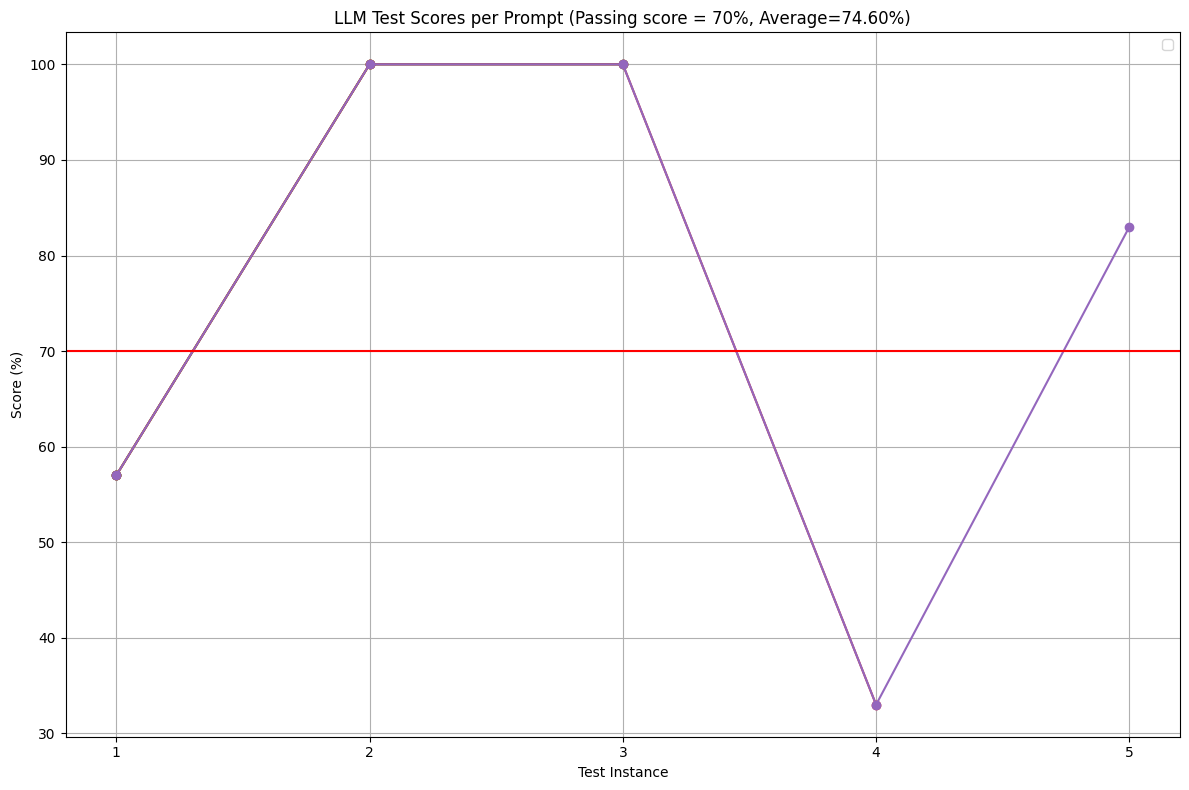

Unified messages: [{'role': 'system', 'content': '\nAnswer on the question, make a research if qneeded.          \nPlease first think out loud before answering.\n\n\nYou have next tools available:\n```\n//Provides reasoning from the perspective of a customer to enhance understanding of customer needs and improve service quality.\n1. Start from best_customer_experience\n```\n<tool_call>\n{\n"tool_name": "best_customer_experience",\n"parameters": {\n"reasoning": "As a customer I want to ..."\n},\n}\n</tool_call>\n## BEST CUSTOMER EXPERIENCE\n{best_customer_experience}\n- best_customer_experience({"reasoning": ... \\ string - (The reasoning from the customer\'s perspective.)})\nCan be called -4 times.\n\n\n//Creates a structured plan with steps to achieve a specific goal. Each step should include expected results, actions to take, and the current state.\n\n2. Continue from making a plan, and after going through each step and mark it you\'re on the step:\n\n<tool_call>\n{\n"tool_name": "ma

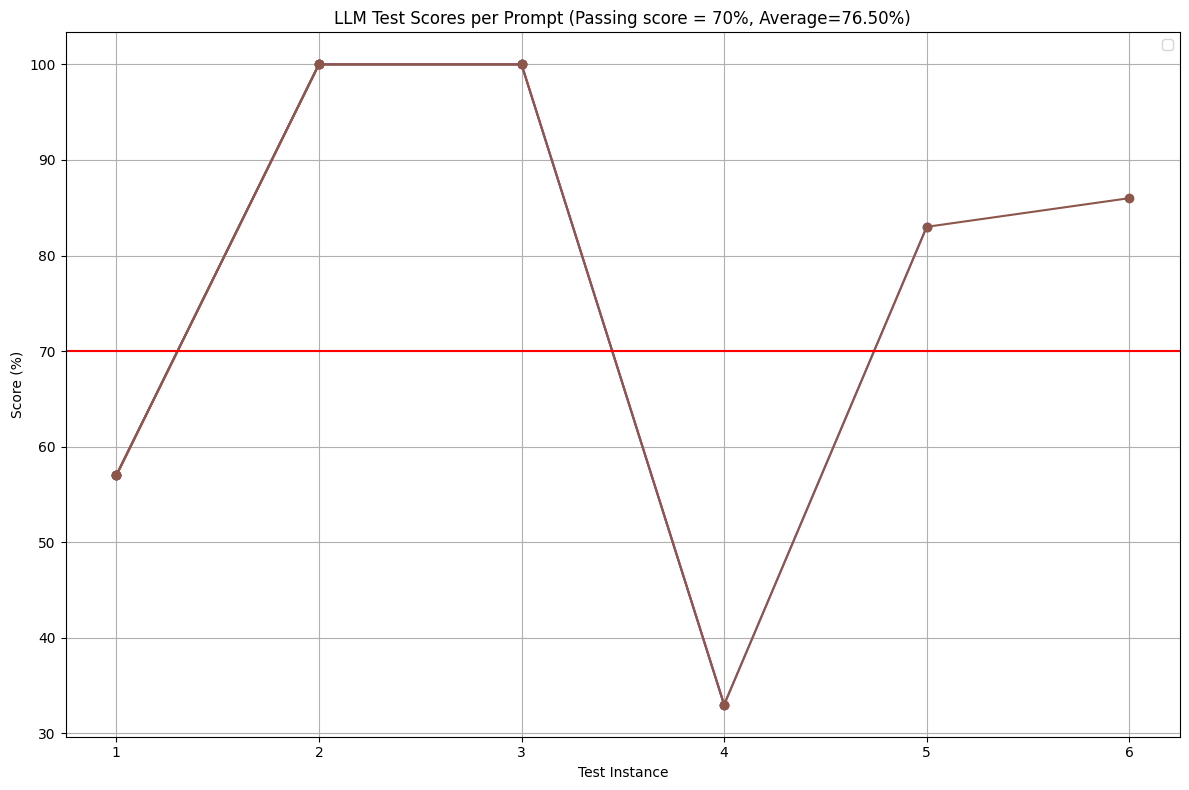

Unified messages: [{'role': 'system', 'content': '\nAnswer on the question, make a research if qneeded.          \nPlease first think out loud before answering.\n\n\nYou have next tools available:\n```\n//Provides reasoning from the perspective of a customer to enhance understanding of customer needs and improve service quality.\n1. Start from best_customer_experience\n```\n<tool_call>\n{\n"tool_name": "best_customer_experience",\n"parameters": {\n"reasoning": "As a customer I want to ..."\n},\n}\n</tool_call>\n## BEST CUSTOMER EXPERIENCE\n{best_customer_experience}\n- best_customer_experience({"reasoning": ... \\ string - (The reasoning from the customer\'s perspective.)})\nCan be called -5 times.\n\n\n//Creates a structured plan with steps to achieve a specific goal. Each step should include expected results, actions to take, and the current state.\n\n2. Continue from making a plan, and after going through each step and mark it you\'re on the step:\n\n<tool_call>\n{\n"tool_name": "ma

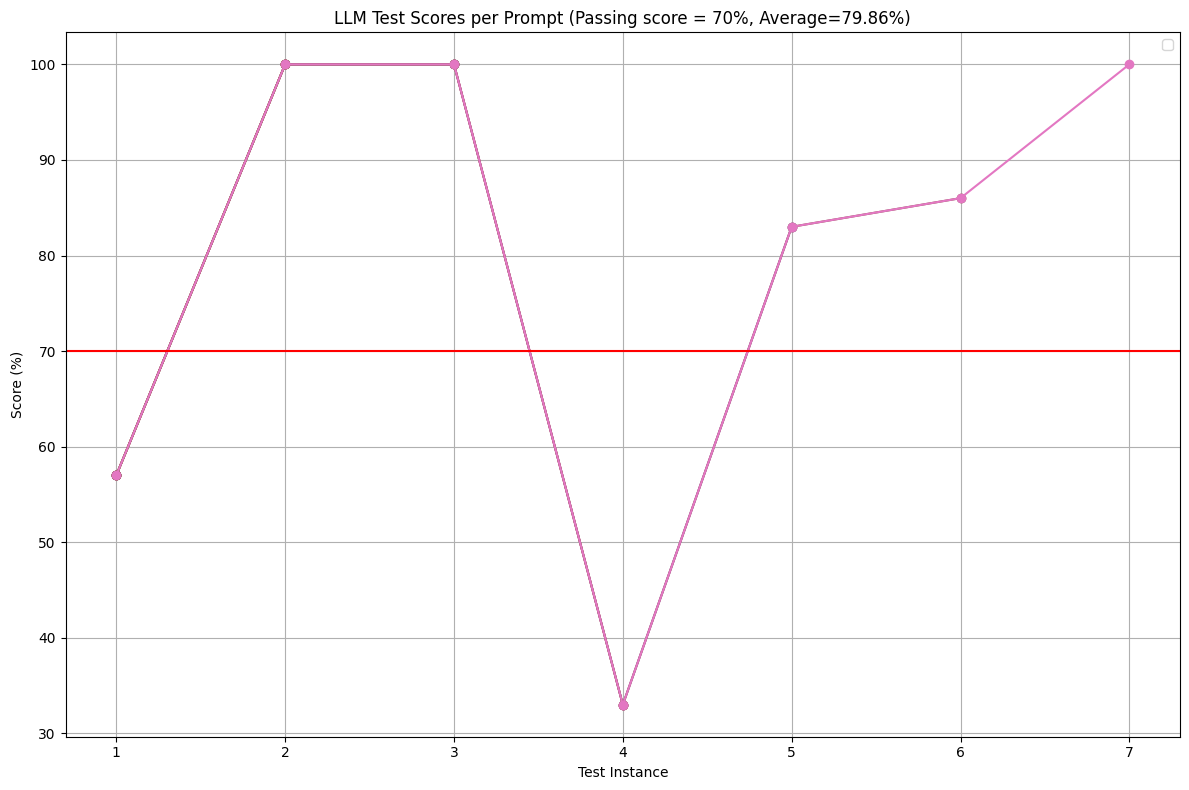

Unified messages: [{'role': 'system', 'content': '\nAnswer on the question, make a research if qneeded.          \nPlease first think out loud before answering.\n\n\nYou have next tools available:\n```\n//Provides reasoning from the perspective of a customer to enhance understanding of customer needs and improve service quality.\n1. Start from best_customer_experience\n```\n<tool_call>\n{\n"tool_name": "best_customer_experience",\n"parameters": {\n"reasoning": "As a customer I want to ..."\n},\n}\n</tool_call>\n## BEST CUSTOMER EXPERIENCE\n{best_customer_experience}\n- best_customer_experience({"reasoning": ... \\ string - (The reasoning from the customer\'s perspective.)})\nCan be called -6 times.\n\n\n//Creates a structured plan with steps to achieve a specific goal. Each step should include expected results, actions to take, and the current state.\n\n2. Continue from making a plan, and after going through each step and mark it you\'re on the step:\n\n<tool_call>\n{\n"tool_name": "ma

Error executing tool 'update_plan', Please try second time.
Traceback (most recent call last):
  File "/Users/kateyanchenka/projects/lamoom-python/researches/../lamoom/ai_models/ai_model.py", line 388, in handle_tool_call
    result = tool_function.execution_function(**parameters)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: update_plan() got an unexpected keyword argument 'step_name'


handled tool call ToolCallResult:
tool_name=update_plan
parameters={'step_name': {'step1': {'expected_results': 'Clarify whether a separate notice of appeal is required before filing the full appeal', 'actions': 'Analyze the information provided in the Board of Supervisors letter and common practices for property tax appeals', 'where_we_are': 'The letter only mentions a 90-day appeal period without specifying a separate notice requirement. Typically, if not mentioned, only the complete appeal is required within the deadline, not a separate notice.'}}}
execution_result=Error executing tool 'update_plan', Please try second time.
update_json_context=False
executed ToolCallResult:
tool_name=update_plan
parameters={'step_name': {'step1': {'expected_results': 'Clarify whether a separate notice of appeal is required before filing the full appeal', 'actions': 'Analyze the information provided in the Board of Supervisors letter and common practices for property tax appeals', 'where_we_are': 'Th

Error executing tool 'update_plan', Please try second time.
Traceback (most recent call last):
  File "/Users/kateyanchenka/projects/lamoom-python/researches/../lamoom/ai_models/ai_model.py", line 388, in handle_tool_call
    result = tool_function.execution_function(**parameters)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: update_plan() got an unexpected keyword argument 'step_name'


handled tool call ToolCallResult:
tool_name=update_plan
parameters={'step_name': 'step1', 'expected_results': 'Clarify whether a separate notice of appeal is required before filing the full appeal', 'actions': 'Analyze the information provided in the Board of Supervisors letter and common practices for property tax appeals', 'where_we_are': 'The letter only mentions a 90-day appeal period without specifying a separate notice requirement. Typically, if not mentioned, only the complete appeal is required within the deadline, not a separate notice.'}
execution_result=Error executing tool 'update_plan', Please try second time.
update_json_context=False
executed ToolCallResult:
tool_name=update_plan
parameters={'step_name': 'step1', 'expected_results': 'Clarify whether a separate notice of appeal is required before filing the full appeal', 'actions': 'Analyze the information provided in the Board of Supervisors letter and common practices for property tax appeals', 'where_we_are': 'The lett

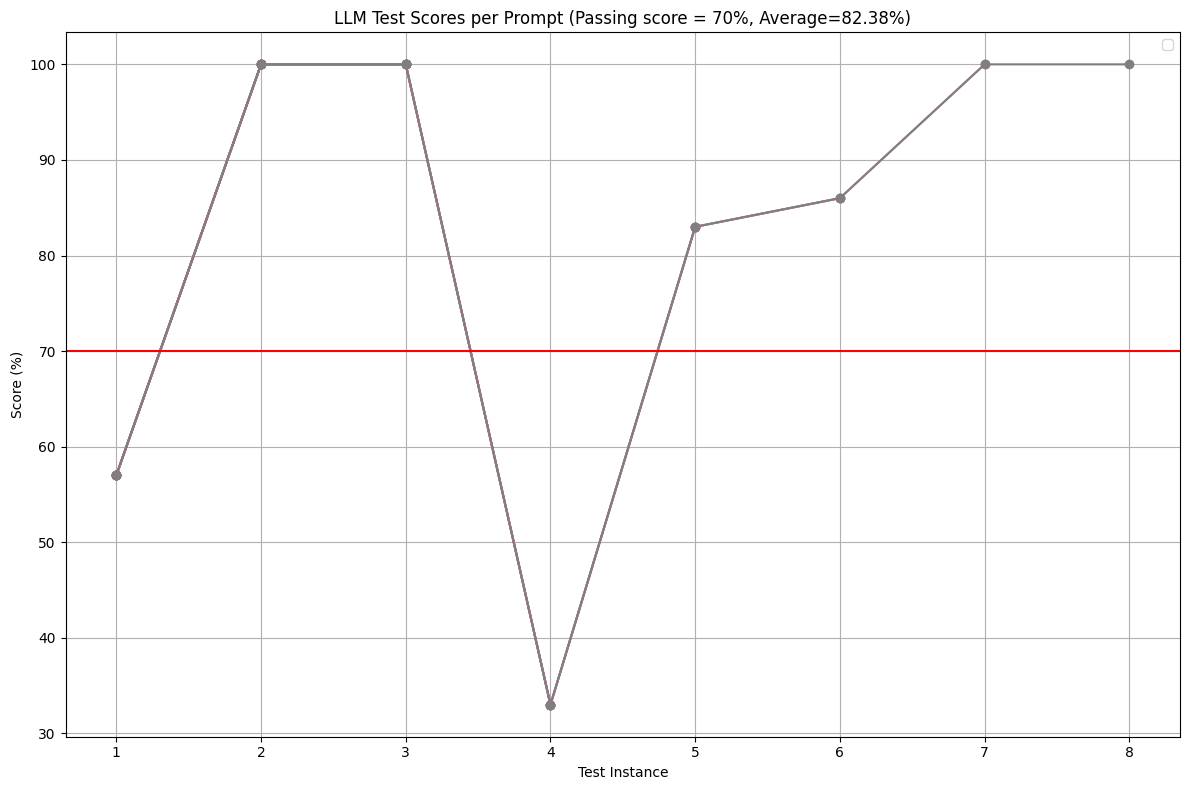

Unified messages: [{'role': 'system', 'content': '\nAnswer on the question, make a research if qneeded.          \nPlease first think out loud before answering.\n\n\nYou have next tools available:\n```\n//Provides reasoning from the perspective of a customer to enhance understanding of customer needs and improve service quality.\n1. Start from best_customer_experience\n```\n<tool_call>\n{\n"tool_name": "best_customer_experience",\n"parameters": {\n"reasoning": "As a customer I want to ..."\n},\n}\n</tool_call>\n## BEST CUSTOMER EXPERIENCE\n{best_customer_experience}\n- best_customer_experience({"reasoning": ... \\ string - (The reasoning from the customer\'s perspective.)})\nCan be called -7 times.\n\n\n//Creates a structured plan with steps to achieve a specific goal. Each step should include expected results, actions to take, and the current state.\n\n2. Continue from making a plan, and after going through each step and mark it you\'re on the step:\n\n<tool_call>\n{\n"tool_name": "ma

Error executing tool 'update_plan', Please try second time.
Traceback (most recent call last):
  File "/Users/kateyanchenka/projects/lamoom-python/researches/../lamoom/ai_models/ai_model.py", line 388, in handle_tool_call
    result = tool_function.execution_function(**parameters)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: update_plan() got an unexpected keyword argument 'step_name'


handled tool call ToolCallResult:
tool_name=update_plan
parameters={'step_name': {'step1': {'expected_results': 'Clarify the legal definition of maritime piracy under U.S. law', 'actions': 'Research the legal definition of piracy in U.S. maritime law and how it differs from regular theft or burglary', 'where_we_are': "Maritime piracy is defined under U.S. law (18 U.S.C. § 1651) as acts committed 'on the high seas' that constitute piracy under international law. True piracy requires: (1) acts on the high seas/outside any state's jurisdiction, (2) violence/detention/robbery for private ends, and (3) typically from one vessel against another vessel. This differs from regular theft/burglary which fall under state criminal laws. Thefts in harbors or coastal waters generally don't qualify as piracy under this definition."}}}
execution_result=Error executing tool 'update_plan', Please try second time.
update_json_context=False
executed ToolCallResult:
tool_name=update_plan
parameters={'step_n

Error executing tool 'update_plan', Please try second time.
Traceback (most recent call last):
  File "/Users/kateyanchenka/projects/lamoom-python/researches/../lamoom/ai_models/ai_model.py", line 388, in handle_tool_call
    result = tool_function.execution_function(**parameters)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: update_plan() got an unexpected keyword argument 'step_name'


handled tool call ToolCallResult:
tool_name=update_plan
parameters={'step_name': 'step1', 'expected_results': 'Clarify the legal definition of maritime piracy under U.S. law', 'actions': 'Research the legal definition of piracy in U.S. maritime law and how it differs from regular theft or burglary', 'where_we_are': "Maritime piracy is defined under U.S. law (18 U.S.C. § 1651) as acts committed 'on the high seas' that constitute piracy under international law. True piracy requires: (1) acts on the high seas/outside any state's jurisdiction, (2) violence/detention/robbery for private ends, and (3) typically from one vessel against another vessel. This differs from regular theft/burglary which fall under state criminal laws. Thefts in harbors or coastal waters generally don't qualify as piracy under this definition."}
execution_result=Error executing tool 'update_plan', Please try second time.
update_json_context=False
executed ToolCallResult:
tool_name=update_plan
parameters={'step_name'

Error executing tool 'update_plan', Please try second time.
Traceback (most recent call last):
  File "/Users/kateyanchenka/projects/lamoom-python/researches/../lamoom/ai_models/ai_model.py", line 388, in handle_tool_call
    result = tool_function.execution_function(**parameters)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: update_plan() got an unexpected keyword argument 'step_name'


handled tool call ToolCallResult:
tool_name=update_plan
parameters={'step_name': 'step1', 'expected_results': 'Clarify the legal definition of maritime piracy under U.S. law', 'actions': 'Research the legal definition of piracy in U.S. maritime law and how it differs from regular theft or burglary', 'where_we_are': "Maritime piracy is defined under U.S. law (18 U.S.C. § 1651) as acts committed 'on the high seas' that constitute piracy under international law. True piracy requires: (1) acts on the high seas/outside any state's jurisdiction, (2) violence/detention/robbery for private ends, and (3) typically from one vessel against another vessel. This differs from regular theft/burglary which fall under state criminal laws. Thefts in harbors or coastal waters generally don't qualify as piracy under this definition."}
execution_result=Error executing tool 'update_plan', Please try second time.
update_json_context=False
executed ToolCallResult:
tool_name=update_plan
parameters={'step_name'

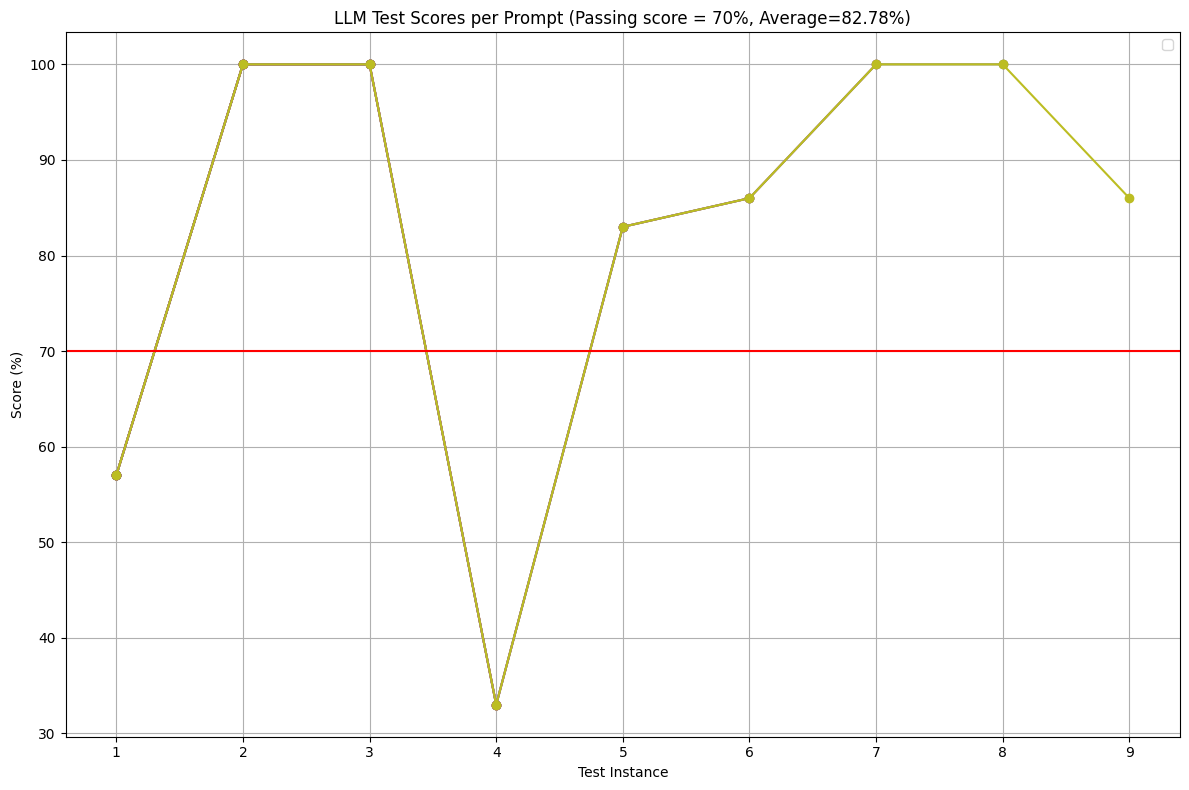

Unified messages: [{'role': 'system', 'content': '\nAnswer on the question, make a research if qneeded.          \nPlease first think out loud before answering.\n\n\nYou have next tools available:\n```\n//Provides reasoning from the perspective of a customer to enhance understanding of customer needs and improve service quality.\n1. Start from best_customer_experience\n```\n<tool_call>\n{\n"tool_name": "best_customer_experience",\n"parameters": {\n"reasoning": "As a customer I want to ..."\n},\n}\n</tool_call>\n## BEST CUSTOMER EXPERIENCE\n{best_customer_experience}\n- best_customer_experience({"reasoning": ... \\ string - (The reasoning from the customer\'s perspective.)})\nCan be called -8 times.\n\n\n//Creates a structured plan with steps to achieve a specific goal. Each step should include expected results, actions to take, and the current state.\n\n2. Continue from making a plan, and after going through each step and mark it you\'re on the step:\n\n<tool_call>\n{\n"tool_name": "ma

Error executing tool 'update_plan', Please try second time.
Traceback (most recent call last):
  File "/Users/kateyanchenka/projects/lamoom-python/researches/../lamoom/ai_models/ai_model.py", line 388, in handle_tool_call
    result = tool_function.execution_function(**parameters)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: update_plan() got an unexpected keyword argument 'step_name'


handled tool call ToolCallResult:
tool_name=update_plan
parameters={'step_name': {'step1': {'expected_results': "Understand California law regarding out-of-state moves with children when there's joint legal custody", 'actions': "Research California's specific requirements for parental relocation, focusing on the legal distinction between physical and legal custody", 'where_we_are': "In California, the parent with physical custody (the 'custodial parent') typically has the presumptive right to relocate with the children. However, when parents share joint legal custody, as in this case, the non-custodial parent can object to the move. California Family Code Section 7501 gives a custodial parent the right to change residence, but this is subject to the court's power to restrain a move that would prejudice the children's rights or welfare. The custodial parent doesn't need to prove the move is 'necessary' but must show it's not detrimental to the children's interests. The non-custodial par

Error executing tool 'update_plan', Please try second time.
Traceback (most recent call last):
  File "/Users/kateyanchenka/projects/lamoom-python/researches/../lamoom/ai_models/ai_model.py", line 388, in handle_tool_call
    result = tool_function.execution_function(**parameters)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: update_plan() got an unexpected keyword argument 'step_name'


handled tool call ToolCallResult:
tool_name=update_plan
parameters={'step_name': 'step1', 'expected_results': "Understand California law regarding out-of-state moves with children when there's joint legal custody", 'actions': "Research California's specific requirements for parental relocation, focusing on the legal distinction between physical and legal custody", 'where_we_are': "In California, the parent with physical custody (the 'custodial parent') typically has the presumptive right to relocate with the children. However, when parents share joint legal custody, as in this case, the non-custodial parent can object to the move. California Family Code Section 7501 gives a custodial parent the right to change residence, but this is subject to the court's power to restrain a move that would prejudice the children's rights or welfare. The custodial parent doesn't need to prove the move is 'necessary' but must show it's not detrimental to the children's interests. The non-custodial paren

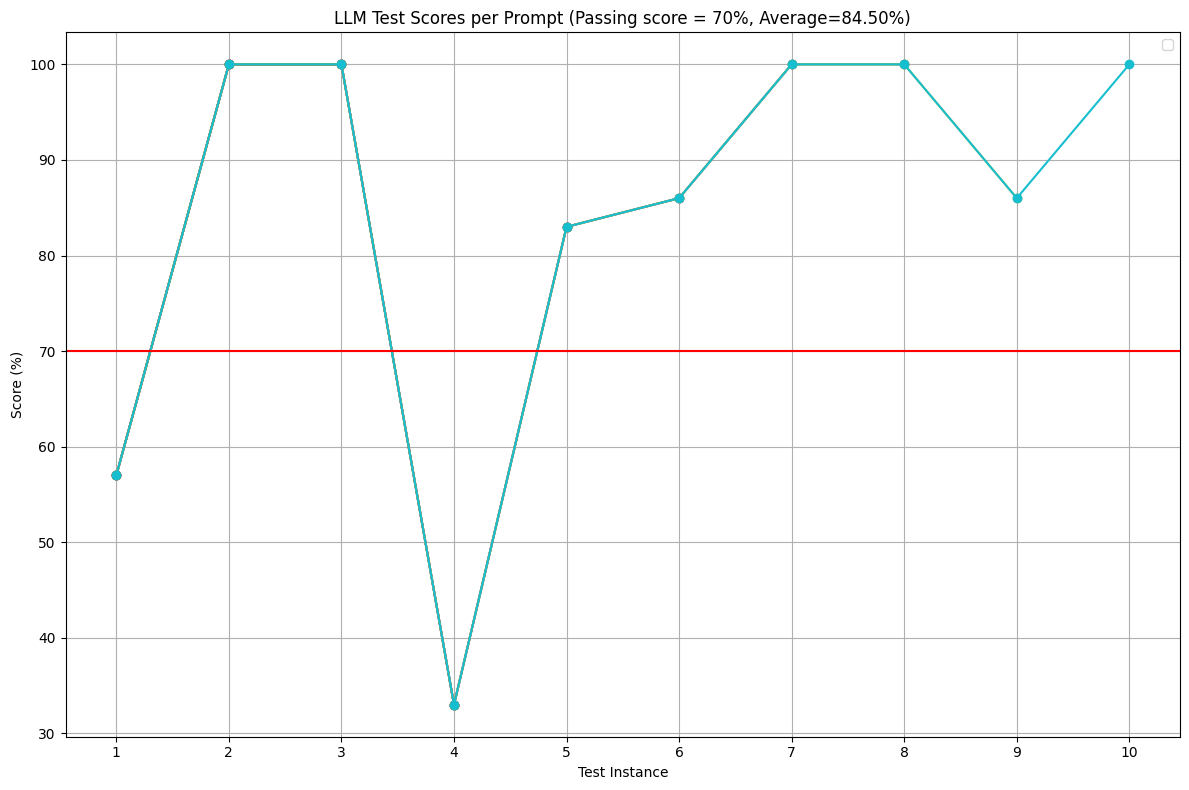

Unified messages: [{'role': 'system', 'content': '\nAnswer on the question, make a research if qneeded.          \nPlease first think out loud before answering.\n\n\nYou have next tools available:\n```\n//Provides reasoning from the perspective of a customer to enhance understanding of customer needs and improve service quality.\n1. Start from best_customer_experience\n```\n<tool_call>\n{\n"tool_name": "best_customer_experience",\n"parameters": {\n"reasoning": "As a customer I want to ..."\n},\n}\n</tool_call>\n## BEST CUSTOMER EXPERIENCE\n{best_customer_experience}\n- best_customer_experience({"reasoning": ... \\ string - (The reasoning from the customer\'s perspective.)})\nCan be called -9 times.\n\n\n//Creates a structured plan with steps to achieve a specific goal. Each step should include expected results, actions to take, and the current state.\n\n2. Continue from making a plan, and after going through each step and mark it you\'re on the step:\n\n<tool_call>\n{\n"tool_name": "ma

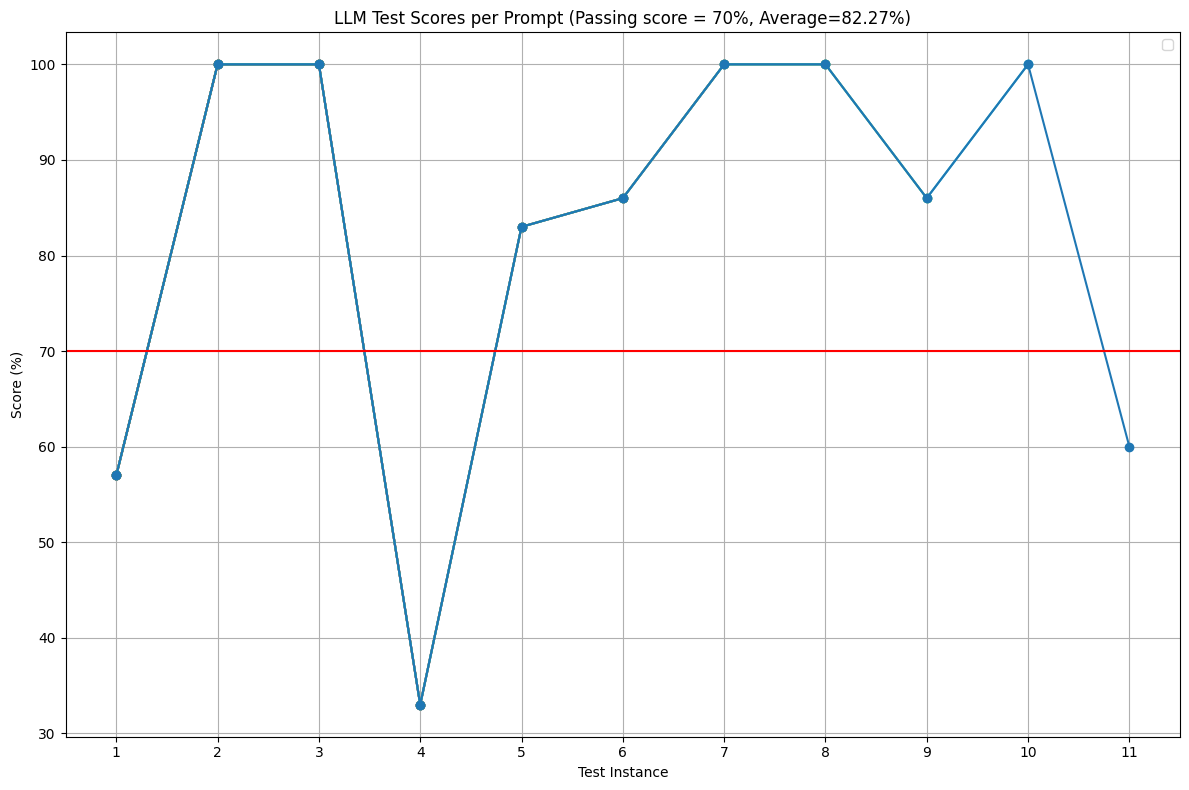

Unified messages: [{'role': 'system', 'content': '\nAnswer on the question, make a research if qneeded.          \nPlease first think out loud before answering.\n\n\nYou have next tools available:\n```\n//Provides reasoning from the perspective of a customer to enhance understanding of customer needs and improve service quality.\n1. Start from best_customer_experience\n```\n<tool_call>\n{\n"tool_name": "best_customer_experience",\n"parameters": {\n"reasoning": "As a customer I want to ..."\n},\n}\n</tool_call>\n## BEST CUSTOMER EXPERIENCE\n{best_customer_experience}\n- best_customer_experience({"reasoning": ... \\ string - (The reasoning from the customer\'s perspective.)})\nCan be called -10 times.\n\n\n//Creates a structured plan with steps to achieve a specific goal. Each step should include expected results, actions to take, and the current state.\n\n2. Continue from making a plan, and after going through each step and mark it you\'re on the step:\n\n<tool_call>\n{\n"tool_name": "m

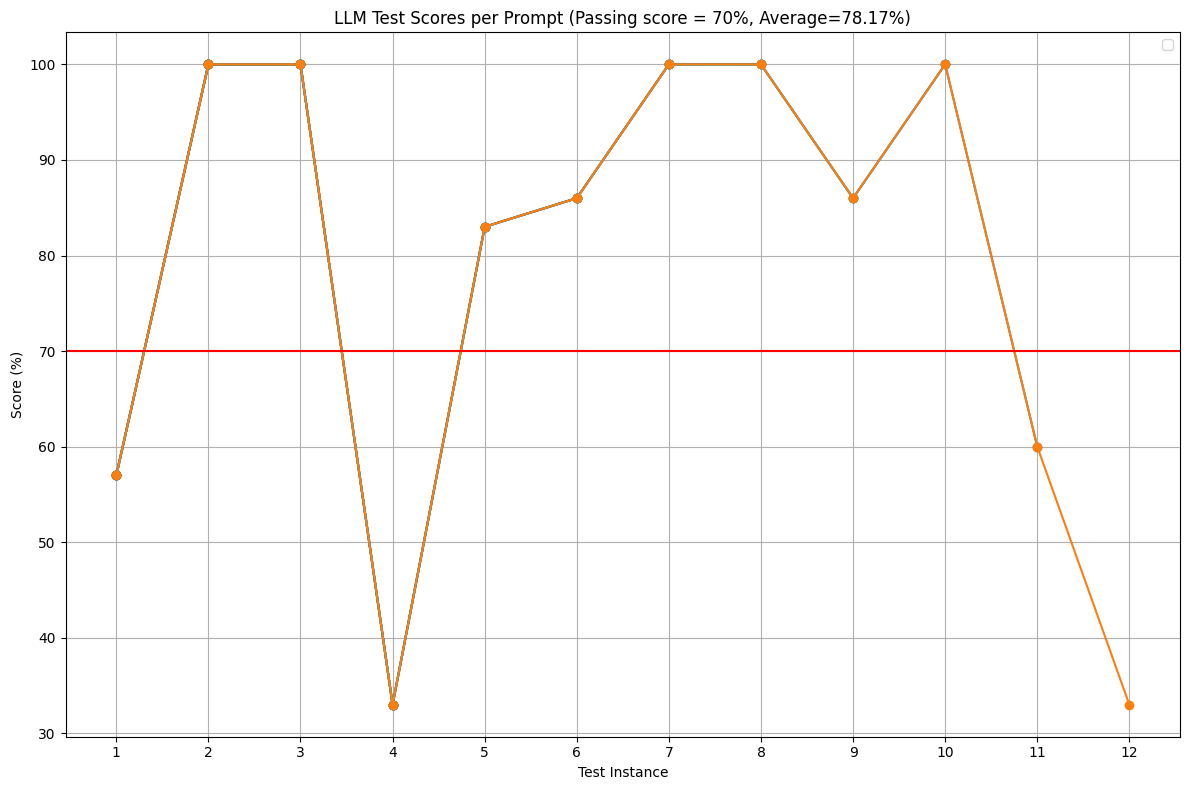

Unified messages: [{'role': 'system', 'content': '\nAnswer on the question, make a research if qneeded.          \nPlease first think out loud before answering.\n\n\nYou have next tools available:\n```\n//Provides reasoning from the perspective of a customer to enhance understanding of customer needs and improve service quality.\n1. Start from best_customer_experience\n```\n<tool_call>\n{\n"tool_name": "best_customer_experience",\n"parameters": {\n"reasoning": "As a customer I want to ..."\n},\n}\n</tool_call>\n## BEST CUSTOMER EXPERIENCE\n{best_customer_experience}\n- best_customer_experience({"reasoning": ... \\ string - (The reasoning from the customer\'s perspective.)})\nCan be called -11 times.\n\n\n//Creates a structured plan with steps to achieve a specific goal. Each step should include expected results, actions to take, and the current state.\n\n2. Continue from making a plan, and after going through each step and mark it you\'re on the step:\n\n<tool_call>\n{\n"tool_name": "m

Error executing tool 'update_plan', Please try second time.
Traceback (most recent call last):
  File "/Users/kateyanchenka/projects/lamoom-python/researches/../lamoom/ai_models/ai_model.py", line 388, in handle_tool_call
    result = tool_function.execution_function(**parameters)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: update_plan() got an unexpected keyword argument 'step_name'


handled tool call ToolCallResult:
tool_name=update_plan
parameters={'step_name': {'step1': {'expected_results': "Understand what constitutes an 'official farm name' in Tennessee", 'actions': "Research the different types of farm registrations in Tennessee and what makes a farm name 'official'", 'where_we_are': "In Tennessee, an 'official farm name' typically refers to either registering a business entity (LLC, corporation) with the Secretary of State, filing a DBA (Doing Business As) with the county clerk, or registering with the Tennessee Department of Agriculture for programs and exemptions."}}}
execution_result=Error executing tool 'update_plan', Please try second time.
update_json_context=False
executed ToolCallResult:
tool_name=update_plan
parameters={'step_name': {'step1': {'expected_results': "Understand what constitutes an 'official farm name' in Tennessee", 'actions': "Research the different types of farm registrations in Tennessee and what makes a farm name 'official'", 'wher

Error executing tool 'update_plan', Please try second time.
Traceback (most recent call last):
  File "/Users/kateyanchenka/projects/lamoom-python/researches/../lamoom/ai_models/ai_model.py", line 388, in handle_tool_call
    result = tool_function.execution_function(**parameters)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: update_plan() got an unexpected keyword argument 'step_name'


handled tool call ToolCallResult:
tool_name=update_plan
parameters={'step_name': 'step1', 'expected_results': "Understand what constitutes an 'official farm name' in Tennessee", 'actions': "Research the different types of farm registrations in Tennessee and what makes a farm name 'official'", 'where_we_are': "In Tennessee, an 'official farm name' typically refers to either registering a business entity (LLC, corporation) with the Secretary of State, filing a DBA (Doing Business As) with the county clerk, or registering with the Tennessee Department of Agriculture for programs and exemptions."}
execution_result=Error executing tool 'update_plan', Please try second time.
update_json_context=False
executed ToolCallResult:
tool_name=update_plan
parameters={'step_name': 'step1', 'expected_results': "Understand what constitutes an 'official farm name' in Tennessee", 'actions': "Research the different types of farm registrations in Tennessee and what makes a farm name 'official'", 'where_we_a

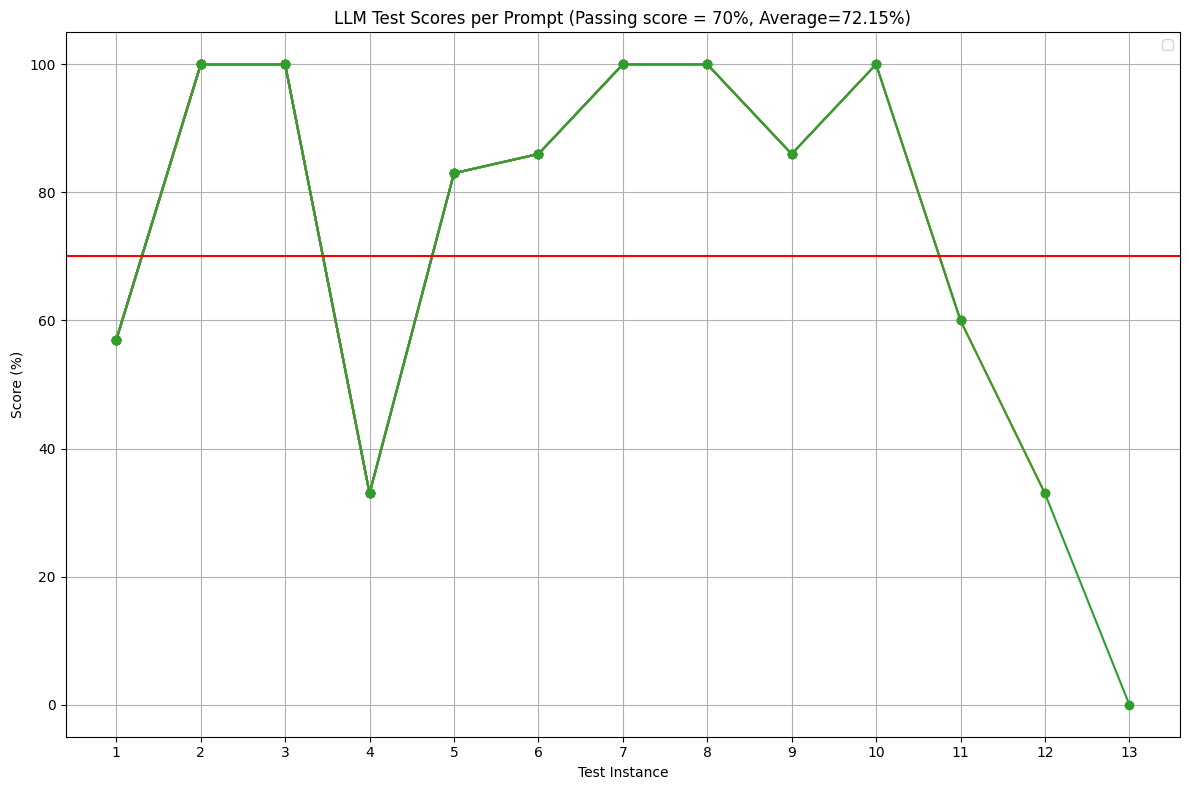

Unified messages: [{'role': 'system', 'content': '\nAnswer on the question, make a research if qneeded.          \nPlease first think out loud before answering.\n\n\nYou have next tools available:\n```\n//Provides reasoning from the perspective of a customer to enhance understanding of customer needs and improve service quality.\n1. Start from best_customer_experience\n```\n<tool_call>\n{\n"tool_name": "best_customer_experience",\n"parameters": {\n"reasoning": "As a customer I want to ..."\n},\n}\n</tool_call>\n## BEST CUSTOMER EXPERIENCE\n{best_customer_experience}\n- best_customer_experience({"reasoning": ... \\ string - (The reasoning from the customer\'s perspective.)})\nCan be called -12 times.\n\n\n//Creates a structured plan with steps to achieve a specific goal. Each step should include expected results, actions to take, and the current state.\n\n2. Continue from making a plan, and after going through each step and mark it you\'re on the step:\n\n<tool_call>\n{\n"tool_name": "m

Error executing tool 'update_plan', Please try second time.
Traceback (most recent call last):
  File "/Users/kateyanchenka/projects/lamoom-python/researches/../lamoom/ai_models/ai_model.py", line 388, in handle_tool_call
    result = tool_function.execution_function(**parameters)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: update_plan() got an unexpected keyword argument 'step_name'


handled tool call ToolCallResult:
tool_name=update_plan
parameters={'step_name': {'step1': {'expected_results': 'Understand general smoking regulations for public spaces near commercial buildings', 'actions': 'Analyze common smoking distance requirements and public space regulations', 'where_we_are': 'Most jurisdictions have smoking distance requirements of 3-10 meters from building entrances. Being 9 meters away would typically comply with these regulations. However, rules can vary by location and may apply differently to shared commercial spaces.'}}}
execution_result=Error executing tool 'update_plan', Please try second time.
update_json_context=False
executed ToolCallResult:
tool_name=update_plan
parameters={'step_name': {'step1': {'expected_results': 'Understand general smoking regulations for public spaces near commercial buildings', 'actions': 'Analyze common smoking distance requirements and public space regulations', 'where_we_are': 'Most jurisdictions have smoking distance req

Error executing tool 'update_plan', Please try second time.
Traceback (most recent call last):
  File "/Users/kateyanchenka/projects/lamoom-python/researches/../lamoom/ai_models/ai_model.py", line 388, in handle_tool_call
    result = tool_function.execution_function(**parameters)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: update_plan() got an unexpected keyword argument 'step_name'


handled tool call ToolCallResult:
tool_name=update_plan
parameters={'step_name': 'step1', 'expected_results': 'Understand general smoking regulations for public spaces near commercial buildings', 'actions': 'Analyze common smoking distance requirements and public space regulations', 'where_we_are': 'Most jurisdictions have smoking distance requirements of 3-10 meters from building entrances. Being 9 meters away would typically comply with these regulations. However, rules can vary by location and may apply differently to shared commercial spaces.'}
execution_result=Error executing tool 'update_plan', Please try second time.
update_json_context=False
executed ToolCallResult:
tool_name=update_plan
parameters={'step_name': 'step1', 'expected_results': 'Understand general smoking regulations for public spaces near commercial buildings', 'actions': 'Analyze common smoking distance requirements and public space regulations', 'where_we_are': 'Most jurisdictions have smoking distance requireme

Error executing tool 'update_plan', Please try second time.
Traceback (most recent call last):
  File "/Users/kateyanchenka/projects/lamoom-python/researches/../lamoom/ai_models/ai_model.py", line 388, in handle_tool_call
    result = tool_function.execution_function(**parameters)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: update_plan() got an unexpected keyword argument 'step_name'


handled tool call ToolCallResult:
tool_name=update_plan
parameters={'step_name': 'step1', 'expected_results': 'Understand general smoking regulations for public spaces near commercial buildings', 'actions': 'Analyze common smoking distance requirements and public space regulations', 'where_we_are': 'Most jurisdictions have smoking distance requirements of 3-10 meters from building entrances. Being 9 meters away would typically comply with these regulations. However, rules can vary by location and may apply differently to shared commercial spaces.'}
execution_result=Error executing tool 'update_plan', Please try second time.
update_json_context=False
executed ToolCallResult:
tool_name=update_plan
parameters={'step_name': 'step1', 'expected_results': 'Understand general smoking regulations for public spaces near commercial buildings', 'actions': 'Analyze common smoking distance requirements and public space regulations', 'where_we_are': 'Most jurisdictions have smoking distance requireme

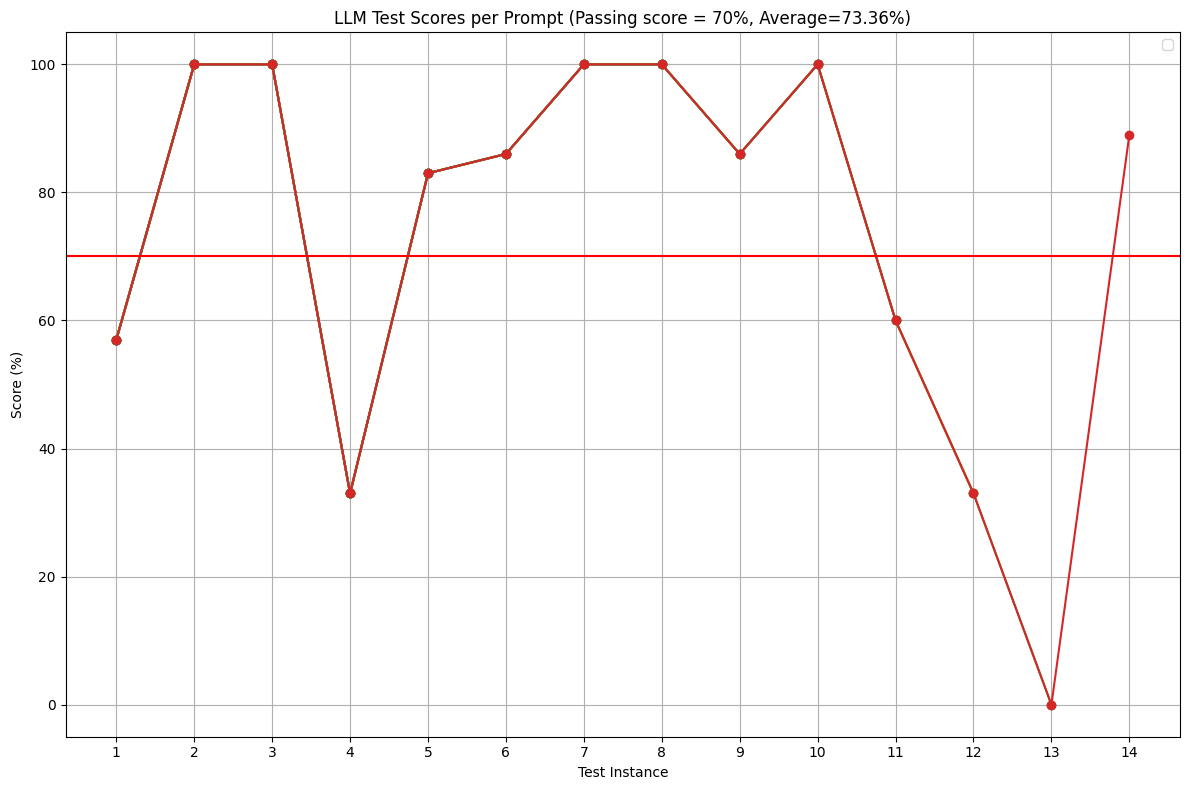

Unified messages: [{'role': 'system', 'content': '\nAnswer on the question, make a research if qneeded.          \nPlease first think out loud before answering.\n\n\nYou have next tools available:\n```\n//Provides reasoning from the perspective of a customer to enhance understanding of customer needs and improve service quality.\n1. Start from best_customer_experience\n```\n<tool_call>\n{\n"tool_name": "best_customer_experience",\n"parameters": {\n"reasoning": "As a customer I want to ..."\n},\n}\n</tool_call>\n## BEST CUSTOMER EXPERIENCE\n{best_customer_experience}\n- best_customer_experience({"reasoning": ... \\ string - (The reasoning from the customer\'s perspective.)})\nCan be called -13 times.\n\n\n//Creates a structured plan with steps to achieve a specific goal. Each step should include expected results, actions to take, and the current state.\n\n2. Continue from making a plan, and after going through each step and mark it you\'re on the step:\n\n<tool_call>\n{\n"tool_name": "m

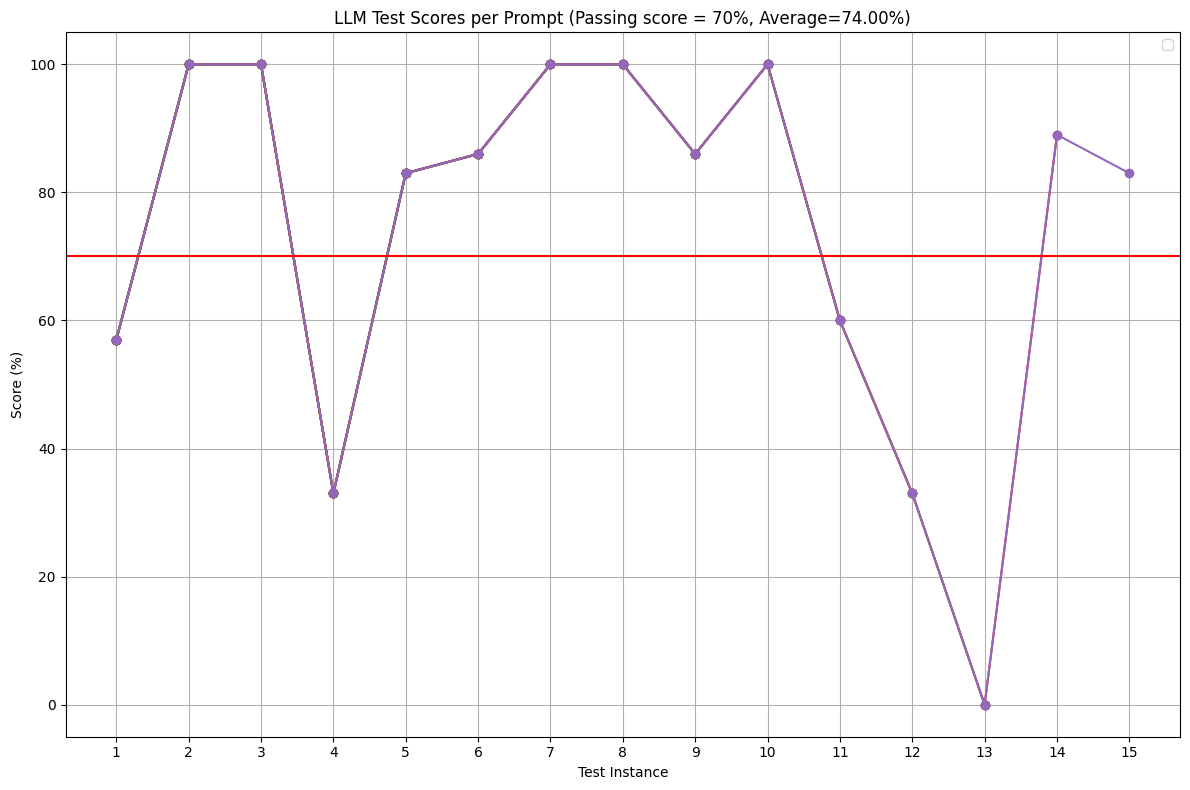

Unified messages: [{'role': 'system', 'content': '\nAnswer on the question, make a research if qneeded.          \nPlease first think out loud before answering.\n\n\nYou have next tools available:\n```\n//Provides reasoning from the perspective of a customer to enhance understanding of customer needs and improve service quality.\n1. Start from best_customer_experience\n```\n<tool_call>\n{\n"tool_name": "best_customer_experience",\n"parameters": {\n"reasoning": "As a customer I want to ..."\n},\n}\n</tool_call>\n## BEST CUSTOMER EXPERIENCE\n{best_customer_experience}\n- best_customer_experience({"reasoning": ... \\ string - (The reasoning from the customer\'s perspective.)})\nCan be called -14 times.\n\n\n//Creates a structured plan with steps to achieve a specific goal. Each step should include expected results, actions to take, and the current state.\n\n2. Continue from making a plan, and after going through each step and mark it you\'re on the step:\n\n<tool_call>\n{\n"tool_name": "m

Error executing tool 'update_plan', Please try second time.
Traceback (most recent call last):
  File "/Users/kateyanchenka/projects/lamoom-python/researches/../lamoom/ai_models/ai_model.py", line 388, in handle_tool_call
    result = tool_function.execution_function(**parameters)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: update_plan() got an unexpected keyword argument 'step_name'


handled tool call ToolCallResult:
tool_name=update_plan
parameters={'step_name': {'step1': {'expected_results': 'Understand the legal classification of bad checks in Georgia', 'actions': 'Research whether bad checks are treated as civil matters, criminal matters, or both in Georgia', 'where_we_are': 'In Georgia, bad checks can be handled as both civil and criminal matters. Criminally, they fall under theft by deception (O.C.G.A. § 16-8-15). Civilly, creditors can pursue the check amount plus fees and damages. Intent to defraud is a key element for criminal prosecution.'}}}
execution_result=Error executing tool 'update_plan', Please try second time.
update_json_context=False
executed ToolCallResult:
tool_name=update_plan
parameters={'step_name': {'step1': {'expected_results': 'Understand the legal classification of bad checks in Georgia', 'actions': 'Research whether bad checks are treated as civil matters, criminal matters, or both in Georgia', 'where_we_are': 'In Georgia, bad checks c

Error executing tool 'update_plan', Please try second time.
Traceback (most recent call last):
  File "/Users/kateyanchenka/projects/lamoom-python/researches/../lamoom/ai_models/ai_model.py", line 388, in handle_tool_call
    result = tool_function.execution_function(**parameters)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: update_plan() got an unexpected keyword argument 'step_name'


handled tool call ToolCallResult:
tool_name=update_plan
parameters={'step_name': 'step1', 'expected_results': 'Understand the legal classification of bad checks in Georgia', 'actions': 'Research whether bad checks are treated as civil matters, criminal matters, or both in Georgia', 'where_we_are': 'In Georgia, bad checks can be handled as both civil and criminal matters. Criminally, they fall under theft by deception (O.C.G.A. § 16-8-15). Civilly, creditors can pursue the check amount plus fees and damages. Intent to defraud is a key element for criminal prosecution.'}
execution_result=Error executing tool 'update_plan', Please try second time.
update_json_context=False
executed ToolCallResult:
tool_name=update_plan
parameters={'step_name': 'step1', 'expected_results': 'Understand the legal classification of bad checks in Georgia', 'actions': 'Research whether bad checks are treated as civil matters, criminal matters, or both in Georgia', 'where_we_are': 'In Georgia, bad checks can be 

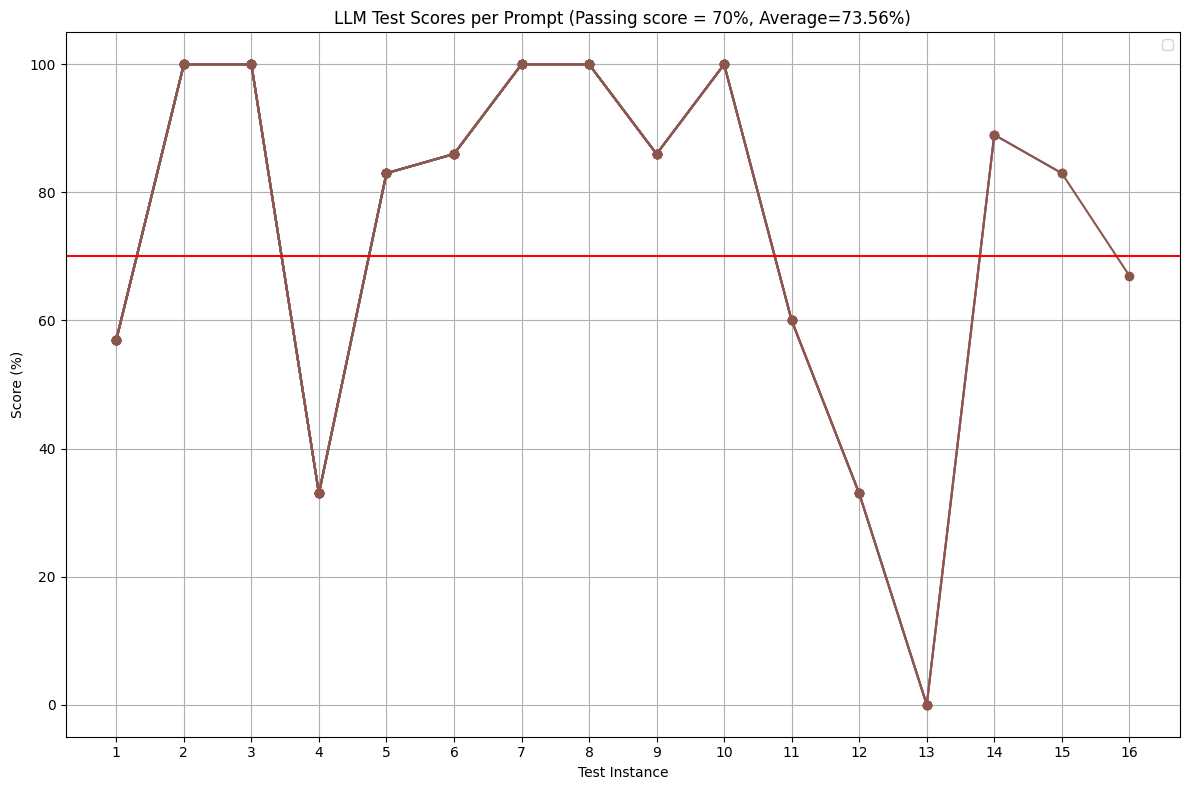

Unified messages: [{'role': 'system', 'content': '\nAnswer on the question, make a research if qneeded.          \nPlease first think out loud before answering.\n\n\nYou have next tools available:\n```\n//Provides reasoning from the perspective of a customer to enhance understanding of customer needs and improve service quality.\n1. Start from best_customer_experience\n```\n<tool_call>\n{\n"tool_name": "best_customer_experience",\n"parameters": {\n"reasoning": "As a customer I want to ..."\n},\n}\n</tool_call>\n## BEST CUSTOMER EXPERIENCE\n{best_customer_experience}\n- best_customer_experience({"reasoning": ... \\ string - (The reasoning from the customer\'s perspective.)})\nCan be called -15 times.\n\n\n//Creates a structured plan with steps to achieve a specific goal. Each step should include expected results, actions to take, and the current state.\n\n2. Continue from making a plan, and after going through each step and mark it you\'re on the step:\n\n<tool_call>\n{\n"tool_name": "m

Exception during stream processing
Traceback (most recent call last):
  File "/Users/kateyanchenka/projects/lamoom-python/researches/../lamoom/ai_models/claude/claude_model.py", line 93, in streaming
    for text_chunk in stream.text_stream:
  File "/Users/kateyanchenka/projects/lamoom-python/.venv/lib/python3.12/site-packages/anthropic/lib/streaming/_messages.py", line 130, in __stream_text__
    for chunk in self:
  File "/Users/kateyanchenka/projects/lamoom-python/.venv/lib/python3.12/site-packages/anthropic/lib/streaming/_messages.py", line 59, in __iter__
    for item in self._iterator:
  File "/Users/kateyanchenka/projects/lamoom-python/.venv/lib/python3.12/site-packages/anthropic/lib/streaming/_messages.py", line 119, in __stream__
    for sse_event in self._raw_stream:
  File "/Users/kateyanchenka/projects/lamoom-python/.venv/lib/python3.12/site-packages/anthropic/_streaming.py", line 68, in __iter__
    for item in self._iterator:
  File "/Users/kateyanchenka/projects/lamoom-p

Unified messages: [{'role': 'system', 'content': '\nAnswer on the question, make a research if qneeded.          \nPlease first think out loud before answering.\n\n\nYou have next tools available:\n```\n//Provides reasoning from the perspective of a customer to enhance understanding of customer needs and improve service quality.\n1. Start from best_customer_experience\n```\n<tool_call>\n{\n"tool_name": "best_customer_experience",\n"parameters": {\n"reasoning": "As a customer I want to ..."\n},\n}\n</tool_call>\n## BEST CUSTOMER EXPERIENCE\n{best_customer_experience}\n- best_customer_experience({"reasoning": ... \\ string - (The reasoning from the customer\'s perspective.)})\nCan be called -15 times.\n\n\n//Creates a structured plan with steps to achieve a specific goal. Each step should include expected results, actions to take, and the current state.\n\n2. Continue from making a plan, and after going through each step and mark it you\'re on the step:\n\n<tool_call>\n{\n"tool_name": "m

Exception during stream processing
Traceback (most recent call last):
  File "/Users/kateyanchenka/projects/lamoom-python/researches/../lamoom/ai_models/claude/claude_model.py", line 93, in streaming
    for text_chunk in stream.text_stream:
  File "/Users/kateyanchenka/projects/lamoom-python/.venv/lib/python3.12/site-packages/anthropic/lib/streaming/_messages.py", line 130, in __stream_text__
    for chunk in self:
  File "/Users/kateyanchenka/projects/lamoom-python/.venv/lib/python3.12/site-packages/anthropic/lib/streaming/_messages.py", line 59, in __iter__
    for item in self._iterator:
  File "/Users/kateyanchenka/projects/lamoom-python/.venv/lib/python3.12/site-packages/anthropic/lib/streaming/_messages.py", line 119, in __stream__
    for sse_event in self._raw_stream:
  File "/Users/kateyanchenka/projects/lamoom-python/.venv/lib/python3.12/site-packages/anthropic/_streaming.py", line 68, in __iter__
    for item in self._iterator:
  File "/Users/kateyanchenka/projects/lamoom-p

Unified messages: [{'role': 'system', 'content': '\nAnswer on the question, make a research if qneeded.          \nPlease first think out loud before answering.\n\n\nYou have next tools available:\n```\n//Provides reasoning from the perspective of a customer to enhance understanding of customer needs and improve service quality.\n1. Start from best_customer_experience\n```\n<tool_call>\n{\n"tool_name": "best_customer_experience",\n"parameters": {\n"reasoning": "As a customer I want to ..."\n},\n}\n</tool_call>\n## BEST CUSTOMER EXPERIENCE\n{best_customer_experience}\n- best_customer_experience({"reasoning": ... \\ string - (The reasoning from the customer\'s perspective.)})\nCan be called -15 times.\n\n\n//Creates a structured plan with steps to achieve a specific goal. Each step should include expected results, actions to take, and the current state.\n\n2. Continue from making a plan, and after going through each step and mark it you\'re on the step:\n\n<tool_call>\n{\n"tool_name": "m

Exception during stream processing
Traceback (most recent call last):
  File "/Users/kateyanchenka/projects/lamoom-python/researches/../lamoom/ai_models/claude/claude_model.py", line 93, in streaming
    for text_chunk in stream.text_stream:
  File "/Users/kateyanchenka/projects/lamoom-python/.venv/lib/python3.12/site-packages/anthropic/lib/streaming/_messages.py", line 130, in __stream_text__
    for chunk in self:
  File "/Users/kateyanchenka/projects/lamoom-python/.venv/lib/python3.12/site-packages/anthropic/lib/streaming/_messages.py", line 59, in __iter__
    for item in self._iterator:
  File "/Users/kateyanchenka/projects/lamoom-python/.venv/lib/python3.12/site-packages/anthropic/lib/streaming/_messages.py", line 119, in __stream__
    for sse_event in self._raw_stream:
  File "/Users/kateyanchenka/projects/lamoom-python/.venv/lib/python3.12/site-packages/anthropic/_streaming.py", line 68, in __iter__
    for item in self._iterator:
  File "/Users/kateyanchenka/projects/lamoom-p

Unified messages: [{'role': 'system', 'content': '\nAnswer on the question, make a research if qneeded.          \nPlease first think out loud before answering.\n\n\nYou have next tools available:\n```\n//Provides reasoning from the perspective of a customer to enhance understanding of customer needs and improve service quality.\n1. Start from best_customer_experience\n```\n<tool_call>\n{\n"tool_name": "best_customer_experience",\n"parameters": {\n"reasoning": "As a customer I want to ..."\n},\n}\n</tool_call>\n## BEST CUSTOMER EXPERIENCE\n{best_customer_experience}\n- best_customer_experience({"reasoning": ... \\ string - (The reasoning from the customer\'s perspective.)})\nCan be called -15 times.\n\n\n//Creates a structured plan with steps to achieve a specific goal. Each step should include expected results, actions to take, and the current state.\n\n2. Continue from making a plan, and after going through each step and mark it you\'re on the step:\n\n<tool_call>\n{\n"tool_name": "m

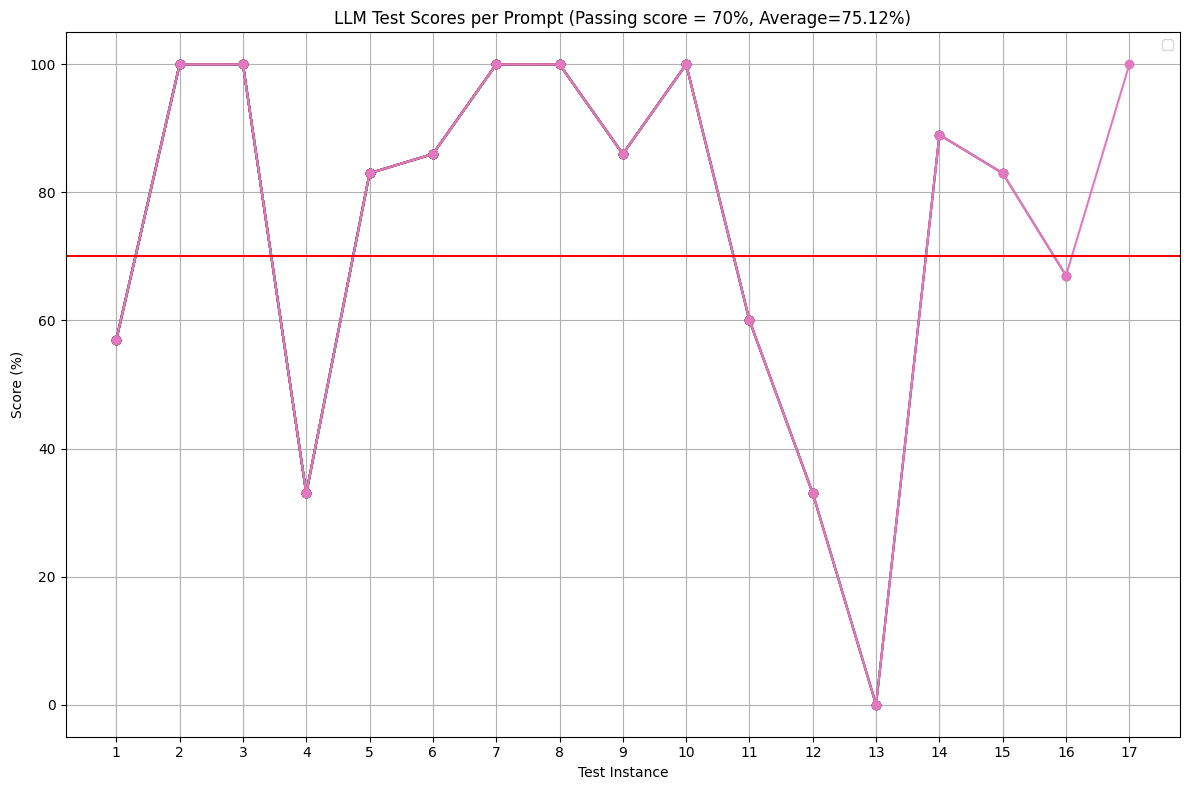

Unified messages: [{'role': 'system', 'content': '\nAnswer on the question, make a research if qneeded.          \nPlease first think out loud before answering.\n\n\nYou have next tools available:\n```\n//Provides reasoning from the perspective of a customer to enhance understanding of customer needs and improve service quality.\n1. Start from best_customer_experience\n```\n<tool_call>\n{\n"tool_name": "best_customer_experience",\n"parameters": {\n"reasoning": "As a customer I want to ..."\n},\n}\n</tool_call>\n## BEST CUSTOMER EXPERIENCE\n{best_customer_experience}\n- best_customer_experience({"reasoning": ... \\ string - (The reasoning from the customer\'s perspective.)})\nCan be called -16 times.\n\n\n//Creates a structured plan with steps to achieve a specific goal. Each step should include expected results, actions to take, and the current state.\n\n2. Continue from making a plan, and after going through each step and mark it you\'re on the step:\n\n<tool_call>\n{\n"tool_name": "m

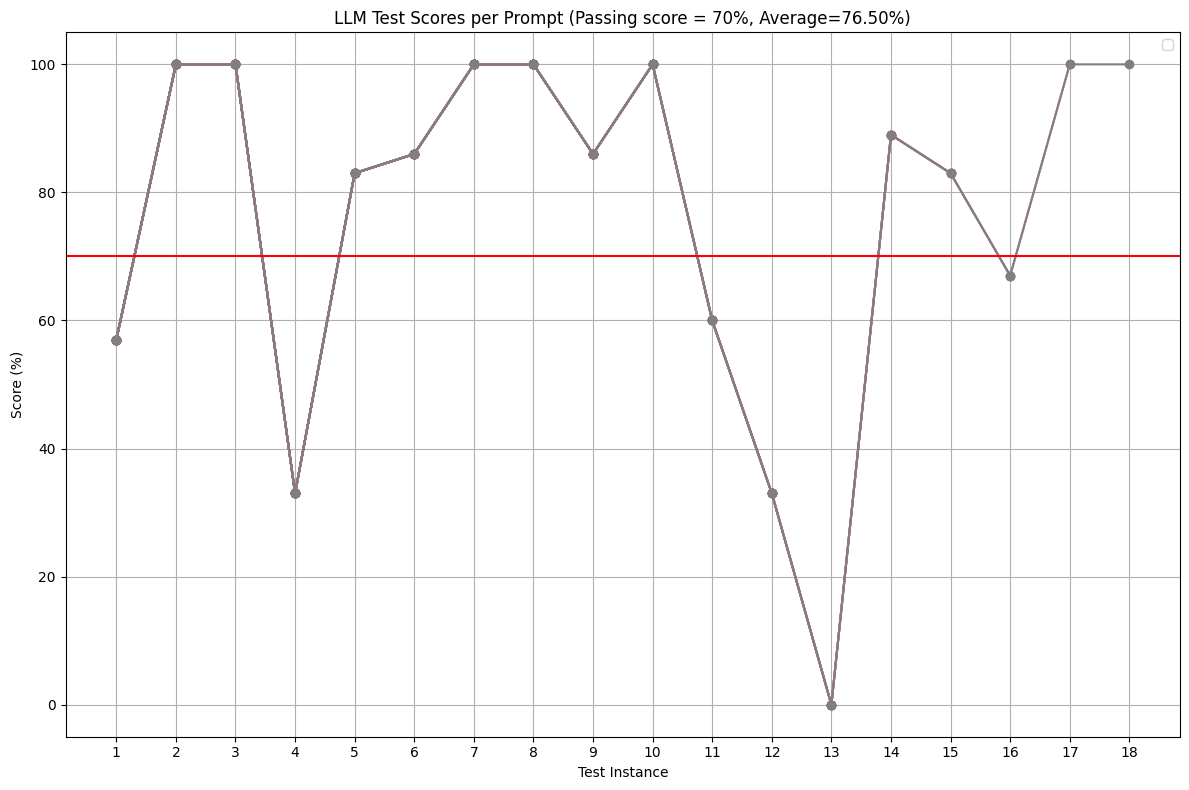

Unified messages: [{'role': 'system', 'content': '\nAnswer on the question, make a research if qneeded.          \nPlease first think out loud before answering.\n\n\nYou have next tools available:\n```\n//Provides reasoning from the perspective of a customer to enhance understanding of customer needs and improve service quality.\n1. Start from best_customer_experience\n```\n<tool_call>\n{\n"tool_name": "best_customer_experience",\n"parameters": {\n"reasoning": "As a customer I want to ..."\n},\n}\n</tool_call>\n## BEST CUSTOMER EXPERIENCE\n{best_customer_experience}\n- best_customer_experience({"reasoning": ... \\ string - (The reasoning from the customer\'s perspective.)})\nCan be called -17 times.\n\n\n//Creates a structured plan with steps to achieve a specific goal. Each step should include expected results, actions to take, and the current state.\n\n2. Continue from making a plan, and after going through each step and mark it you\'re on the step:\n\n<tool_call>\n{\n"tool_name": "m

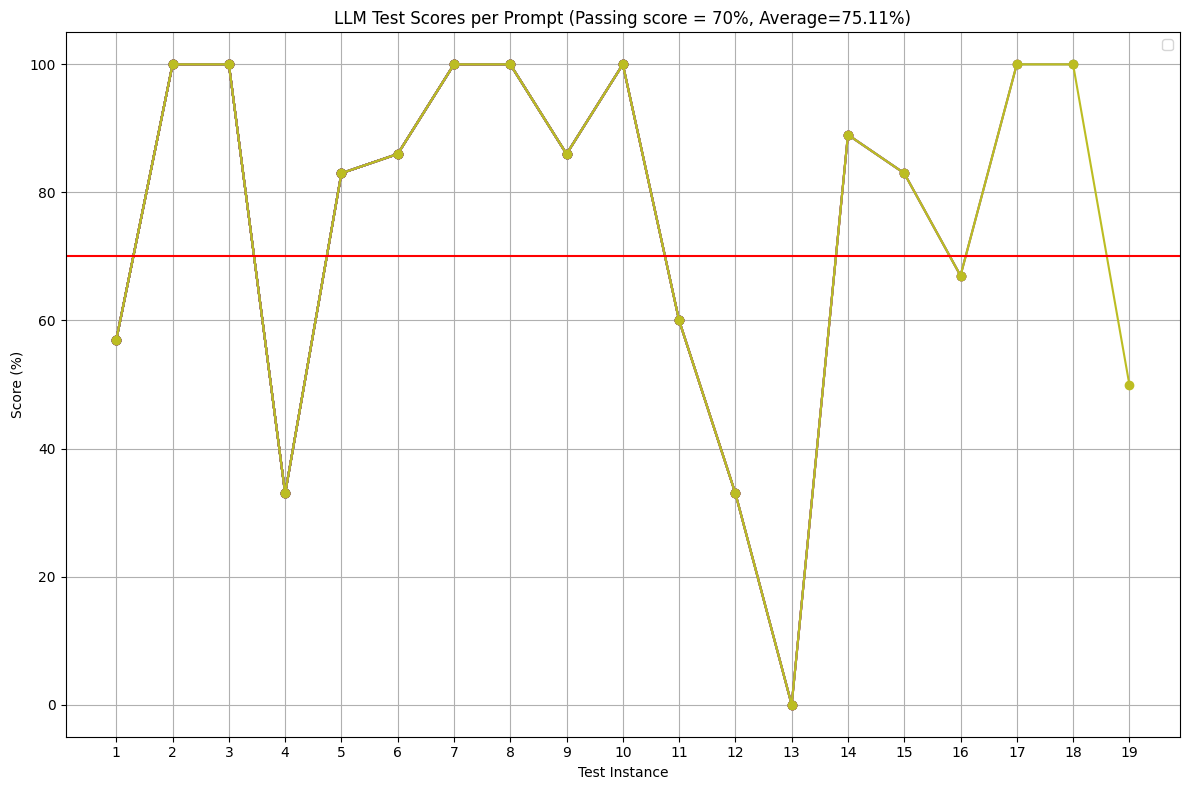

Unified messages: [{'role': 'system', 'content': '\nAnswer on the question, make a research if qneeded.          \nPlease first think out loud before answering.\n\n\nYou have next tools available:\n```\n//Provides reasoning from the perspective of a customer to enhance understanding of customer needs and improve service quality.\n1. Start from best_customer_experience\n```\n<tool_call>\n{\n"tool_name": "best_customer_experience",\n"parameters": {\n"reasoning": "As a customer I want to ..."\n},\n}\n</tool_call>\n## BEST CUSTOMER EXPERIENCE\n{best_customer_experience}\n- best_customer_experience({"reasoning": ... \\ string - (The reasoning from the customer\'s perspective.)})\nCan be called -18 times.\n\n\n//Creates a structured plan with steps to achieve a specific goal. Each step should include expected results, actions to take, and the current state.\n\n2. Continue from making a plan, and after going through each step and mark it you\'re on the step:\n\n<tool_call>\n{\n"tool_name": "m

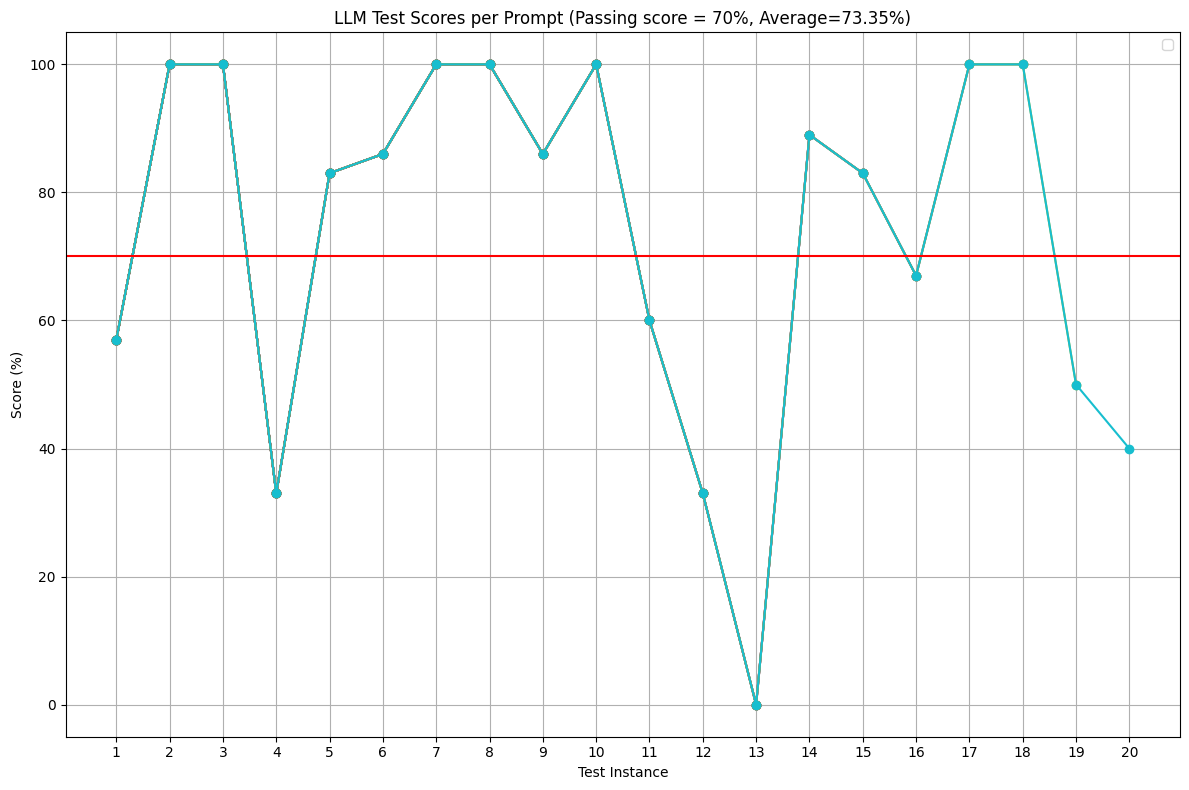

Unified messages: [{'role': 'system', 'content': '\nAnswer on the question, make a research if qneeded.          \nPlease first think out loud before answering.\n\n\nYou have next tools available:\n```\n//Provides reasoning from the perspective of a customer to enhance understanding of customer needs and improve service quality.\n1. Start from best_customer_experience\n```\n<tool_call>\n{\n"tool_name": "best_customer_experience",\n"parameters": {\n"reasoning": "As a customer I want to ..."\n},\n}\n</tool_call>\n## BEST CUSTOMER EXPERIENCE\n{best_customer_experience}\n- best_customer_experience({"reasoning": ... \\ string - (The reasoning from the customer\'s perspective.)})\nCan be called -19 times.\n\n\n//Creates a structured plan with steps to achieve a specific goal. Each step should include expected results, actions to take, and the current state.\n\n2. Continue from making a plan, and after going through each step and mark it you\'re on the step:\n\n<tool_call>\n{\n"tool_name": "m

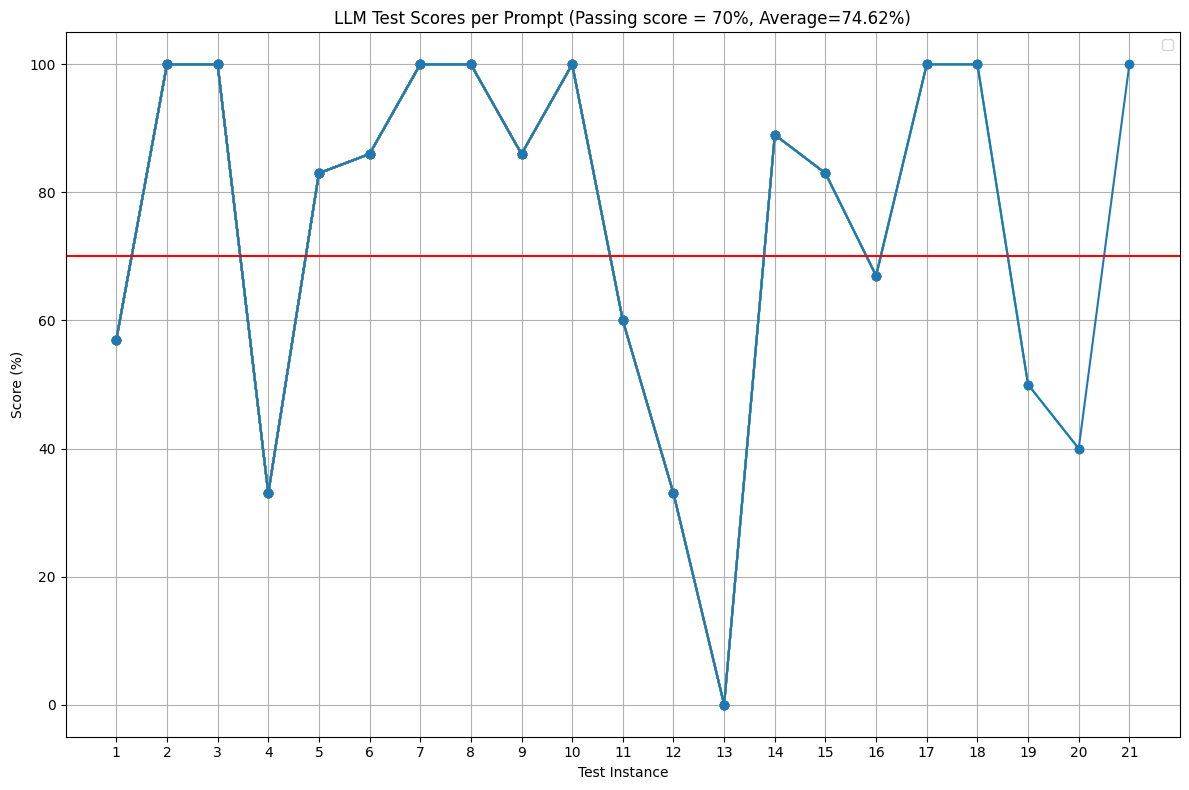

Unified messages: [{'role': 'system', 'content': '\nAnswer on the question, make a research if qneeded.          \nPlease first think out loud before answering.\n\n\nYou have next tools available:\n```\n//Provides reasoning from the perspective of a customer to enhance understanding of customer needs and improve service quality.\n1. Start from best_customer_experience\n```\n<tool_call>\n{\n"tool_name": "best_customer_experience",\n"parameters": {\n"reasoning": "As a customer I want to ..."\n},\n}\n</tool_call>\n## BEST CUSTOMER EXPERIENCE\n{best_customer_experience}\n- best_customer_experience({"reasoning": ... \\ string - (The reasoning from the customer\'s perspective.)})\nCan be called -20 times.\n\n\n//Creates a structured plan with steps to achieve a specific goal. Each step should include expected results, actions to take, and the current state.\n\n2. Continue from making a plan, and after going through each step and mark it you\'re on the step:\n\n<tool_call>\n{\n"tool_name": "m

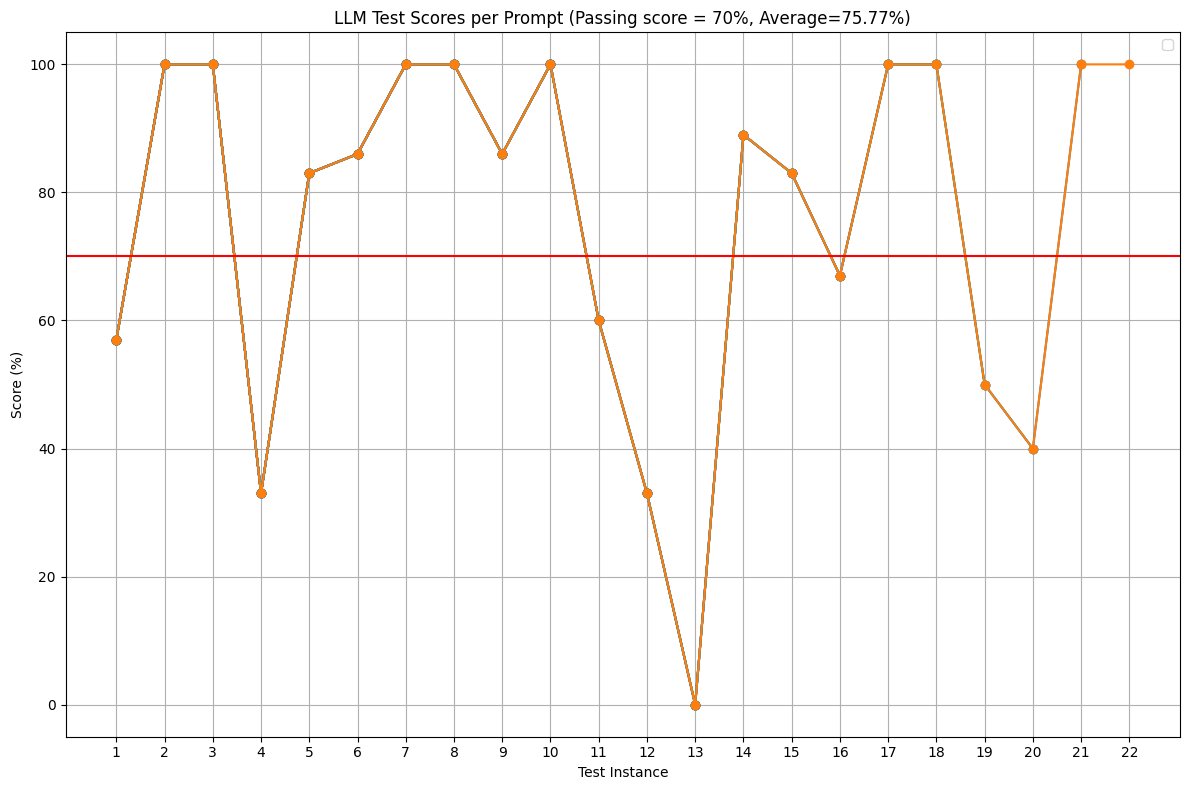

In [12]:

for ideal_answer_statement_ind in ideal_answer_statements:
    for target_model in target_models:
        if target_models_results.get(ideal_answer_statement_ind) and target_models_results[ideal_answer_statement_ind].get(target_model):
            print(f"Skipping already processed model {target_model} for index {ideal_answer_statement_ind}")
            continue
        item = final_df.loc[final_df['index'] == ideal_answer_statement_ind].squeeze()
        question = item['question']
        answer = item['answer']
        response = client.call(agent.id, {"question": question}, model=target_model)
        print(f"\nModel:\n.{target_model}\nResponse:\n{response.content}\n")
        if not response.content:
            print(f"Empty response for model {target_model} and index {ideal_answer_statement_ind}, skipping...")
            continue

        statements = ideal_answer_statements[ideal_answer_statement_ind]
        result = testing_pipes[target_model].compare(
            ideal_answer=answer,
            llm_response=response.content,
            optional_params={'model': target_model, 'index': ideal_answer_statement_ind},
            statements=statements
        )
        if not target_models_results.get(ideal_answer_statement_ind):
            target_models_results[ideal_answer_statement_ind] = {}
        target_models_results[ideal_answer_statement_ind][target_model] = result
        print(f'Result for model {target_model}:\n{result.to_dict()}\n')

    for target_model in target_models:
        print(f"Statistics for model {target_model}:")
        testing_pipes[target_model].visualize_test_results(group_by="prompt_id")

    if ideal_answer_statement_ind > 20:
        break
